In [1]:
library(ComplexHeatmap)
library(readxl)
library(circlize)
library(reshape2)
library(ggplot2)
library(dplyr)
library(stringr)

Loading required package: grid

ComplexHeatmap version 2.10.0
Bioconductor page: http://bioconductor.org/packages/ComplexHeatmap/
Github page: https://github.com/jokergoo/ComplexHeatmap
Documentation: http://jokergoo.github.io/ComplexHeatmap-reference

If you use it in published research, please cite:
Gu, Z. Complex heatmaps reveal patterns and correlations in multidimensional 
  genomic data. Bioinformatics 2016.

The new InteractiveComplexHeatmap package can directly export static 
complex heatmaps into an interactive Shiny app with zero effort. Have a try!

This message can be suppressed by:
  suppressPackageStartupMessages(library(ComplexHeatmap))


circlize version 0.4.13
CRAN page: https://cran.r-project.org/package=circlize
Github page: https://github.com/jokergoo/circlize
Documentation: https://jokergoo.github.io/circlize_book/book/

If you use it in published research, please cite:
Gu, Z. circlize implements and enhances circular visualization
  in R. Bioinformatics 2014.

Thi

In [2]:
data <- list()
sheetlist <- excel_sheets(path="./220114_processed_Long.XLS")

for (metab in sheetlist[1:(length(sheetlist)-2)]){
    tempdf <- read_excel(path="./220114_processed_Long.XLS", sheet = metab, skip=4)
    #print(tempdf["Area"])
    data[[metab]] <- tempdf %>% pull("Area")
}

data = as.data.frame(data)
data = data[2:49,]
print(dim(data))

[1]  48 180


In [3]:
colnames(data) = sheetlist[1:(length(sheetlist)-2)]
data[data == "NF"] = NA
data[] <- lapply(data, function(x) as.numeric(x))
head(data)

,palmitate,alpha-lipoic_acid,N-acetylphenylalanine,methylthioadenosine,N-acetylmethionine,phenylacetyl_glutamine,kynurenic_acid,nicotinamide,C5_carnitines,butyryl_carnitine,⋯,citrate,cis-aconitate,"fructose_1,6-bisphosphate",PRPP,lysine,lysine_13C6-15N2,SAICAR,GTP,arginine,arginine_13C6-15N4
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
2,43492516,NA,89174.79,28591431,936775.61,NA,50247.34,70832816,12446626,115492286,⋯,1424048794,65024614,5287385.7,1236036.173,10498857,28114491,1015946.6,57685171,1286408871,375340028
3,73810609,NA,115982.11,6818094,19286.13,NA,209723.83,7212300,3224290,20212976,⋯,151824808,21712976,596259.2,NA,2246221,4298056,119910.8,4431293,165903079,44019184
4,53583689,NA,75329.14,32620070,977323.66,NA,164500.50,55389175,14539613,129260751,⋯,1234296325,61751961,5399234.7,1211573.849,12894153,33233553,814400.3,41007919,1368652374,408469746
5,49307999,NA,55692.83,33018966,924783.90,NA,222485.36,63346380,13964464,141109573,⋯,1176951002,64230898,5254813.2,9763.634,14447831,33273209,716446.8,36683764,1369508052,375140352
6,40494341,NA,36632.48,14988303,220968.46,NA,279594.50,100787912,4594851,65149438,⋯,704473733,21389484,8043024.6,NA,17138209,25512283,NA,53164451,1408203972,321361377
7,33306183,NA,NA,16189176,167689.95,NA,210876.91,80841940,4959099,73224435,⋯,382476275,17309471,7461695.3,NA,19842596,28072910,NA,27891973,1188538361,293209457


In [4]:
tempdf <- read_excel(path="./220114_processed_Long.XLS", sheet = sheetlist[1], skip=4)
samples = tempdf %>% pull("Sample ID")
rownames(data) = samples[2:49]
# rownames(data) = make.names(as.character(sapply(sample, 
#                                          function(x) str_c(unlist(strsplit(x, ' '))[4], 
#                                                            collapse='_'))), unique=T)
#data["rep"] = as.character(sapply(samples[2:49], function(x) {z = unlist(strsplit(x, ' ')); 
#                                                              str_c(z[(length(z)-1):length(z)], collapse='_')}))
head(data)

,palmitate,alpha-lipoic_acid,N-acetylphenylalanine,methylthioadenosine,N-acetylmethionine,phenylacetyl_glutamine,kynurenic_acid,nicotinamide,C5_carnitines,butyryl_carnitine,⋯,citrate,cis-aconitate,"fructose_1,6-bisphosphate",PRPP,lysine,lysine_13C6-15N2,SAICAR,GTP,arginine,arginine_13C6-15N4
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BD01_THP-1 DMSO rep 1,43492516,NA,89174.79,28591431,936775.61,NA,50247.34,70832816,12446626,115492286,⋯,1424048794,65024614,5287385.7,1236036.173,10498857,28114491,1015946.6,57685171,1286408871,375340028
BD02_THP-1 DMSO rep 2,73810609,NA,115982.11,6818094,19286.13,NA,209723.83,7212300,3224290,20212976,⋯,151824808,21712976,596259.2,NA,2246221,4298056,119910.8,4431293,165903079,44019184
BD03_THP-1 DMSO rep 3,53583689,NA,75329.14,32620070,977323.66,NA,164500.50,55389175,14539613,129260751,⋯,1234296325,61751961,5399234.7,1211573.849,12894153,33233553,814400.3,41007919,1368652374,408469746
BD04_THP-1 DMSO rep 4,49307999,NA,55692.83,33018966,924783.90,NA,222485.36,63346380,13964464,141109573,⋯,1176951002,64230898,5254813.2,9763.634,14447831,33273209,716446.8,36683764,1369508052,375140352
BD05_THP-1 BRQ 500nM rep 1,40494341,NA,36632.48,14988303,220968.46,NA,279594.50,100787912,4594851,65149438,⋯,704473733,21389484,8043024.6,NA,17138209,25512283,NA,53164451,1408203972,321361377
BD06_THP-1 BRQ 500nM rep 2,33306183,NA,NA,16189176,167689.95,NA,210876.91,80841940,4959099,73224435,⋯,382476275,17309471,7461695.3,NA,19842596,28072910,NA,27891973,1188538361,293209457


In [5]:
thp1_data = data[1:12,]
erhoxa9_data = data[13:48,]

In [53]:
# removing metabolites with >20 NA values, and changing the remaining NA values to 0
thp1_data_zero = thp1_data[,apply(thp1_data,2,function(x) sum(is.na(x))) < 10]
thp1_data_zero = t(thp1_data_zero)
# second_to_last = dim(thp1_data_zero)[1]-1
# thp1_data_zero = rbind(thp1_data_zero[second_to_last:(second_to_last+1),], thp1_data_zero[1:(second_to_last-1),])
                        
#colnames(data_zero) = make.names(data_zero[1,], unique = TRUE)
dim(thp1_data_zero)
head(thp1_data_zero)

[1] 162  12

,BD01_THP-1 DMSO rep 1,BD02_THP-1 DMSO rep 2,BD03_THP-1 DMSO rep 3,BD04_THP-1 DMSO rep 4,BD05_THP-1 BRQ 500nM rep 1,BD06_THP-1 BRQ 500nM rep 2,BD07_THP-1 BRQ 500nM rep 3,BD08_THP-1 BRQ 500nM rep 4,BD09_THP-1 HU 100uM rep 1,BD10_THP-1 HU 100uM rep 2,BD11_THP-1 HU 100uM rep 3,BD12_THP-1 HU 100uM rep 4
palmitate,43492516.35,73810609.34,53583688.74,49307998.64,40494341.20,33306182.7,39787556.23,40874062.68,25611711,27477947.43,21141906.98,23409827.0
N-acetylphenylalanine,89174.79,115982.11,75329.14,55692.83,36632.48,NA,32041.53,52523.82,NA,46478.23,38916.44,202515.7
methylthioadenosine,28591431.18,6818094.02,32620070.16,33018966.13,14988303.00,16189176.1,21398150.83,15656396.20,19640381,5776164.34,30155234.28,31138368.7
N-acetylmethionine,936775.61,19286.13,977323.66,924783.90,220968.46,167689.9,254244.36,615245.62,4694772,549065.85,6973548.74,6865161.6
kynurenic_acid,50247.34,209723.83,164500.50,222485.36,279594.50,210876.9,338981.72,342083.88,NA,21429.74,324363.51,NA
nicotinamide,70832815.70,7212300.23,55389174.86,63346379.55,100787911.61,80841939.5,129697605.44,147507754.21,53985452,10516767.27,108184586.00,78673319.6


In [54]:
# normalize for extraction efficiency -- 15N 
# std_rows = data_zero_mat[grepl('valine-13C5-15N', rownames(data_zero_mat)),]
# std_norm_vals = std_rows

std_rows = thp1_data_zero[grepl('15N', rownames(thp1_data_zero)),]
std_rows = std_rows[!(rownames(std_rows) %in% c("methionine_13C6-15N")),]  # this was NA in some of the samples
std_norm_vals = std_rows/apply(std_rows[,c(1,3,4)],1,median, na.rm=T)
std_norm_vals = apply(std_norm_vals,2,median, na.rm=T)

thp1_data_zero_norm = t(t(thp1_data_zero) / std_norm_vals)
thp1_data_zero_norm2 = thp1_data_zero_norm
# options(repr.plot.width=15,repr.plot.height=5)
# boxplot(std_rows/std_rows[,1])
# abline(h=1)

# std_rows = data_zero_mat_norm[grepl('15N', rownames(data_zero_mat)),]
# boxplot(std_rows/std_rows[,1])
# abline(h=1)



In [56]:
# normalize for BCAAs 
bcaa_rows = thp1_data_zero_norm[c("lysine", "valine", "isoleucine", "leucine", "tryptophan"),]
#bcaa_rows = data_zero_norm[c("lysine", "valine", "isoleucine"),]
bcaa_norm_vals = bcaa_rows/apply(bcaa_rows[,c(1:6, 34:36)],1,median)
bcaa_norm_vals = apply(bcaa_norm_vals,2,median, na.rm=T)

thp1_data_zero_norm2 = t(t(thp1_data_zero_norm) / bcaa_norm_vals)

ERROR: Error in bcaa_rows[, c(1:6, 34:36)]: subscript out of bounds


In [63]:
# log fold change compared to NTCs 

thp1_data_zero_norm2[thp1_data_zero_norm2 == 0] = NA
thp1_data_zero_lfc = log2(thp1_data_zero_norm2/apply(thp1_data_zero_norm2[,c(1,3,4)],1,median, na.rm=T))
#data_zero_lfc = log2(data_zero_mat_norm2/data_zero_mat_norm2[,2])  # normalize by #2

thp1_data_zero_lfc[is.infinite(thp1_data_zero_lfc)] = NA
#data_zero_lfc[is.nan(data_zero_lfc)] = NA
thp1_data_zero_lfc = thp1_data_zero_lfc[order(rownames(thp1_data_zero_lfc)),]
thp1_data_zero_lfc = thp1_data_zero_lfc[apply(thp1_data_zero_lfc,1,function(x) sum(is.na(x))) < 12,]

var_vals = apply(thp1_data_zero_lfc,1,function(x) var(x, na.rm=T))

                 

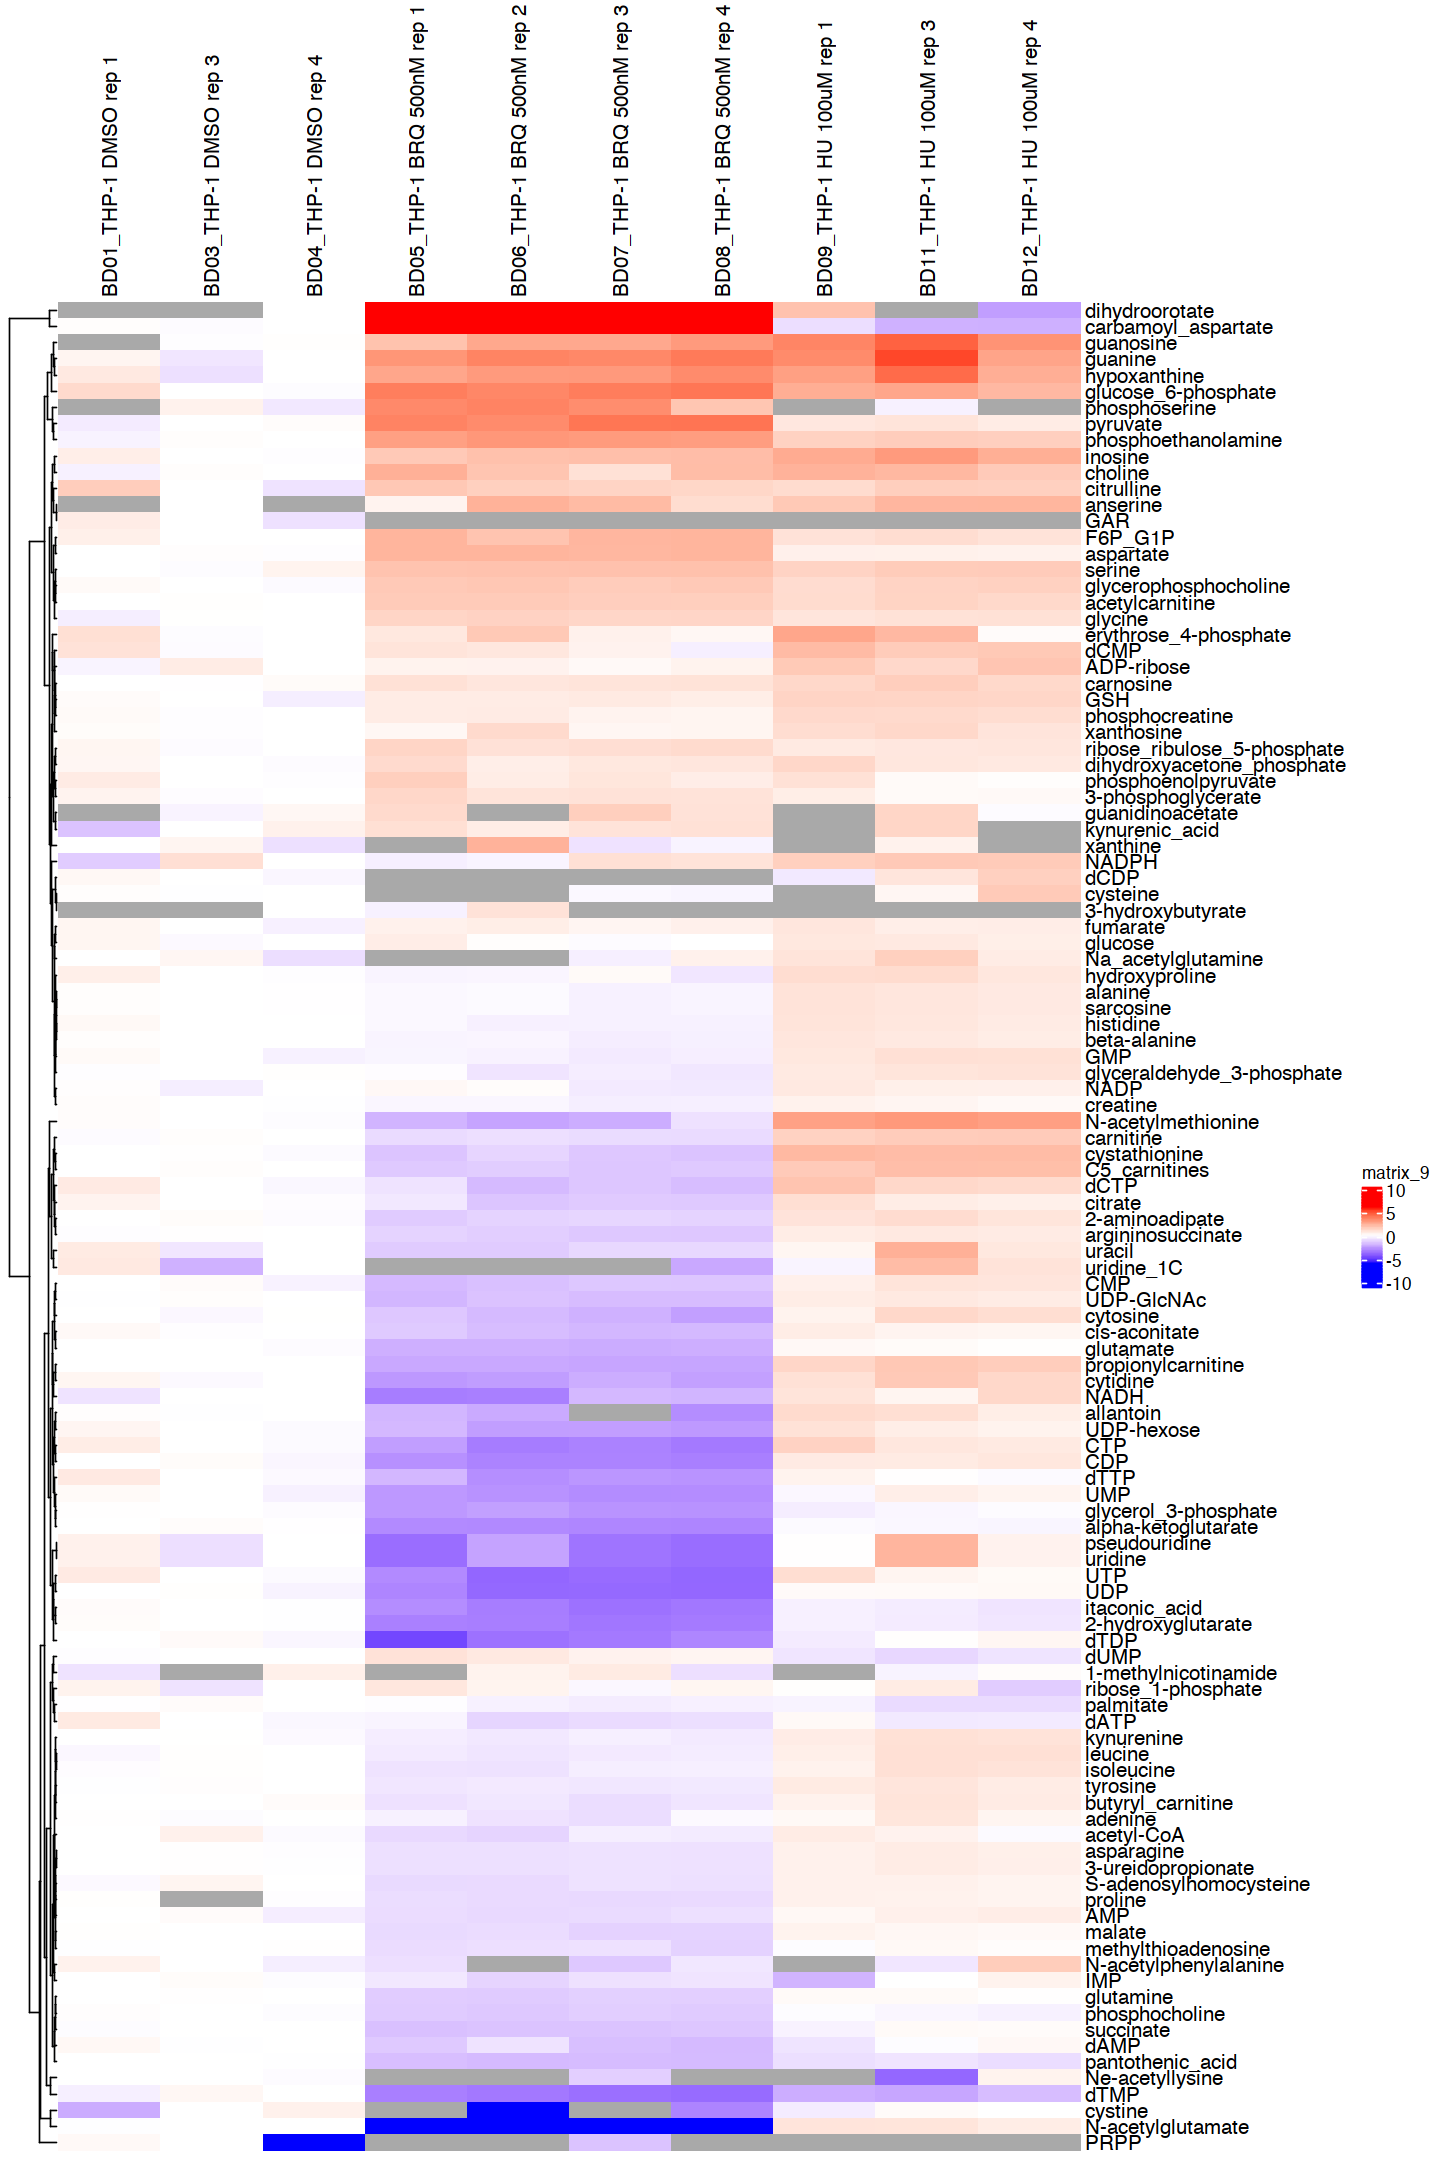

In [69]:
options(repr.plot.width=12,repr.plot.height=18)
col_fun = colorRamp2(c(-6, 0, 6), c("blue", "white", "red"))

thp1_data_zero_lfc_highvar = thp1_data_zero_lfc[var_vals>0.3,]

# pdf("./211120_bd289_heatmap.pdf", width=12, height=10)

# Heatmap(data_zero_lfc_highvar, cluster_columns = FALSE,
#         cluster_rows=TRUE,
#         #row_km = 4, row_km_repeats=100,
#         column_names_side = "top", col=col_fun,
#         na_col="darkgray")

# dev.off()

Heatmap(thp1_data_zero_lfc_highvar[,c(1,3:9,11:12)], cluster_columns = FALSE,
        cluster_rows=TRUE,
        #row_km = 4, row_km_repeats=100,
        column_names_side = "top", col=col_fun,
        na_col="darkgray")

pdf 
  2

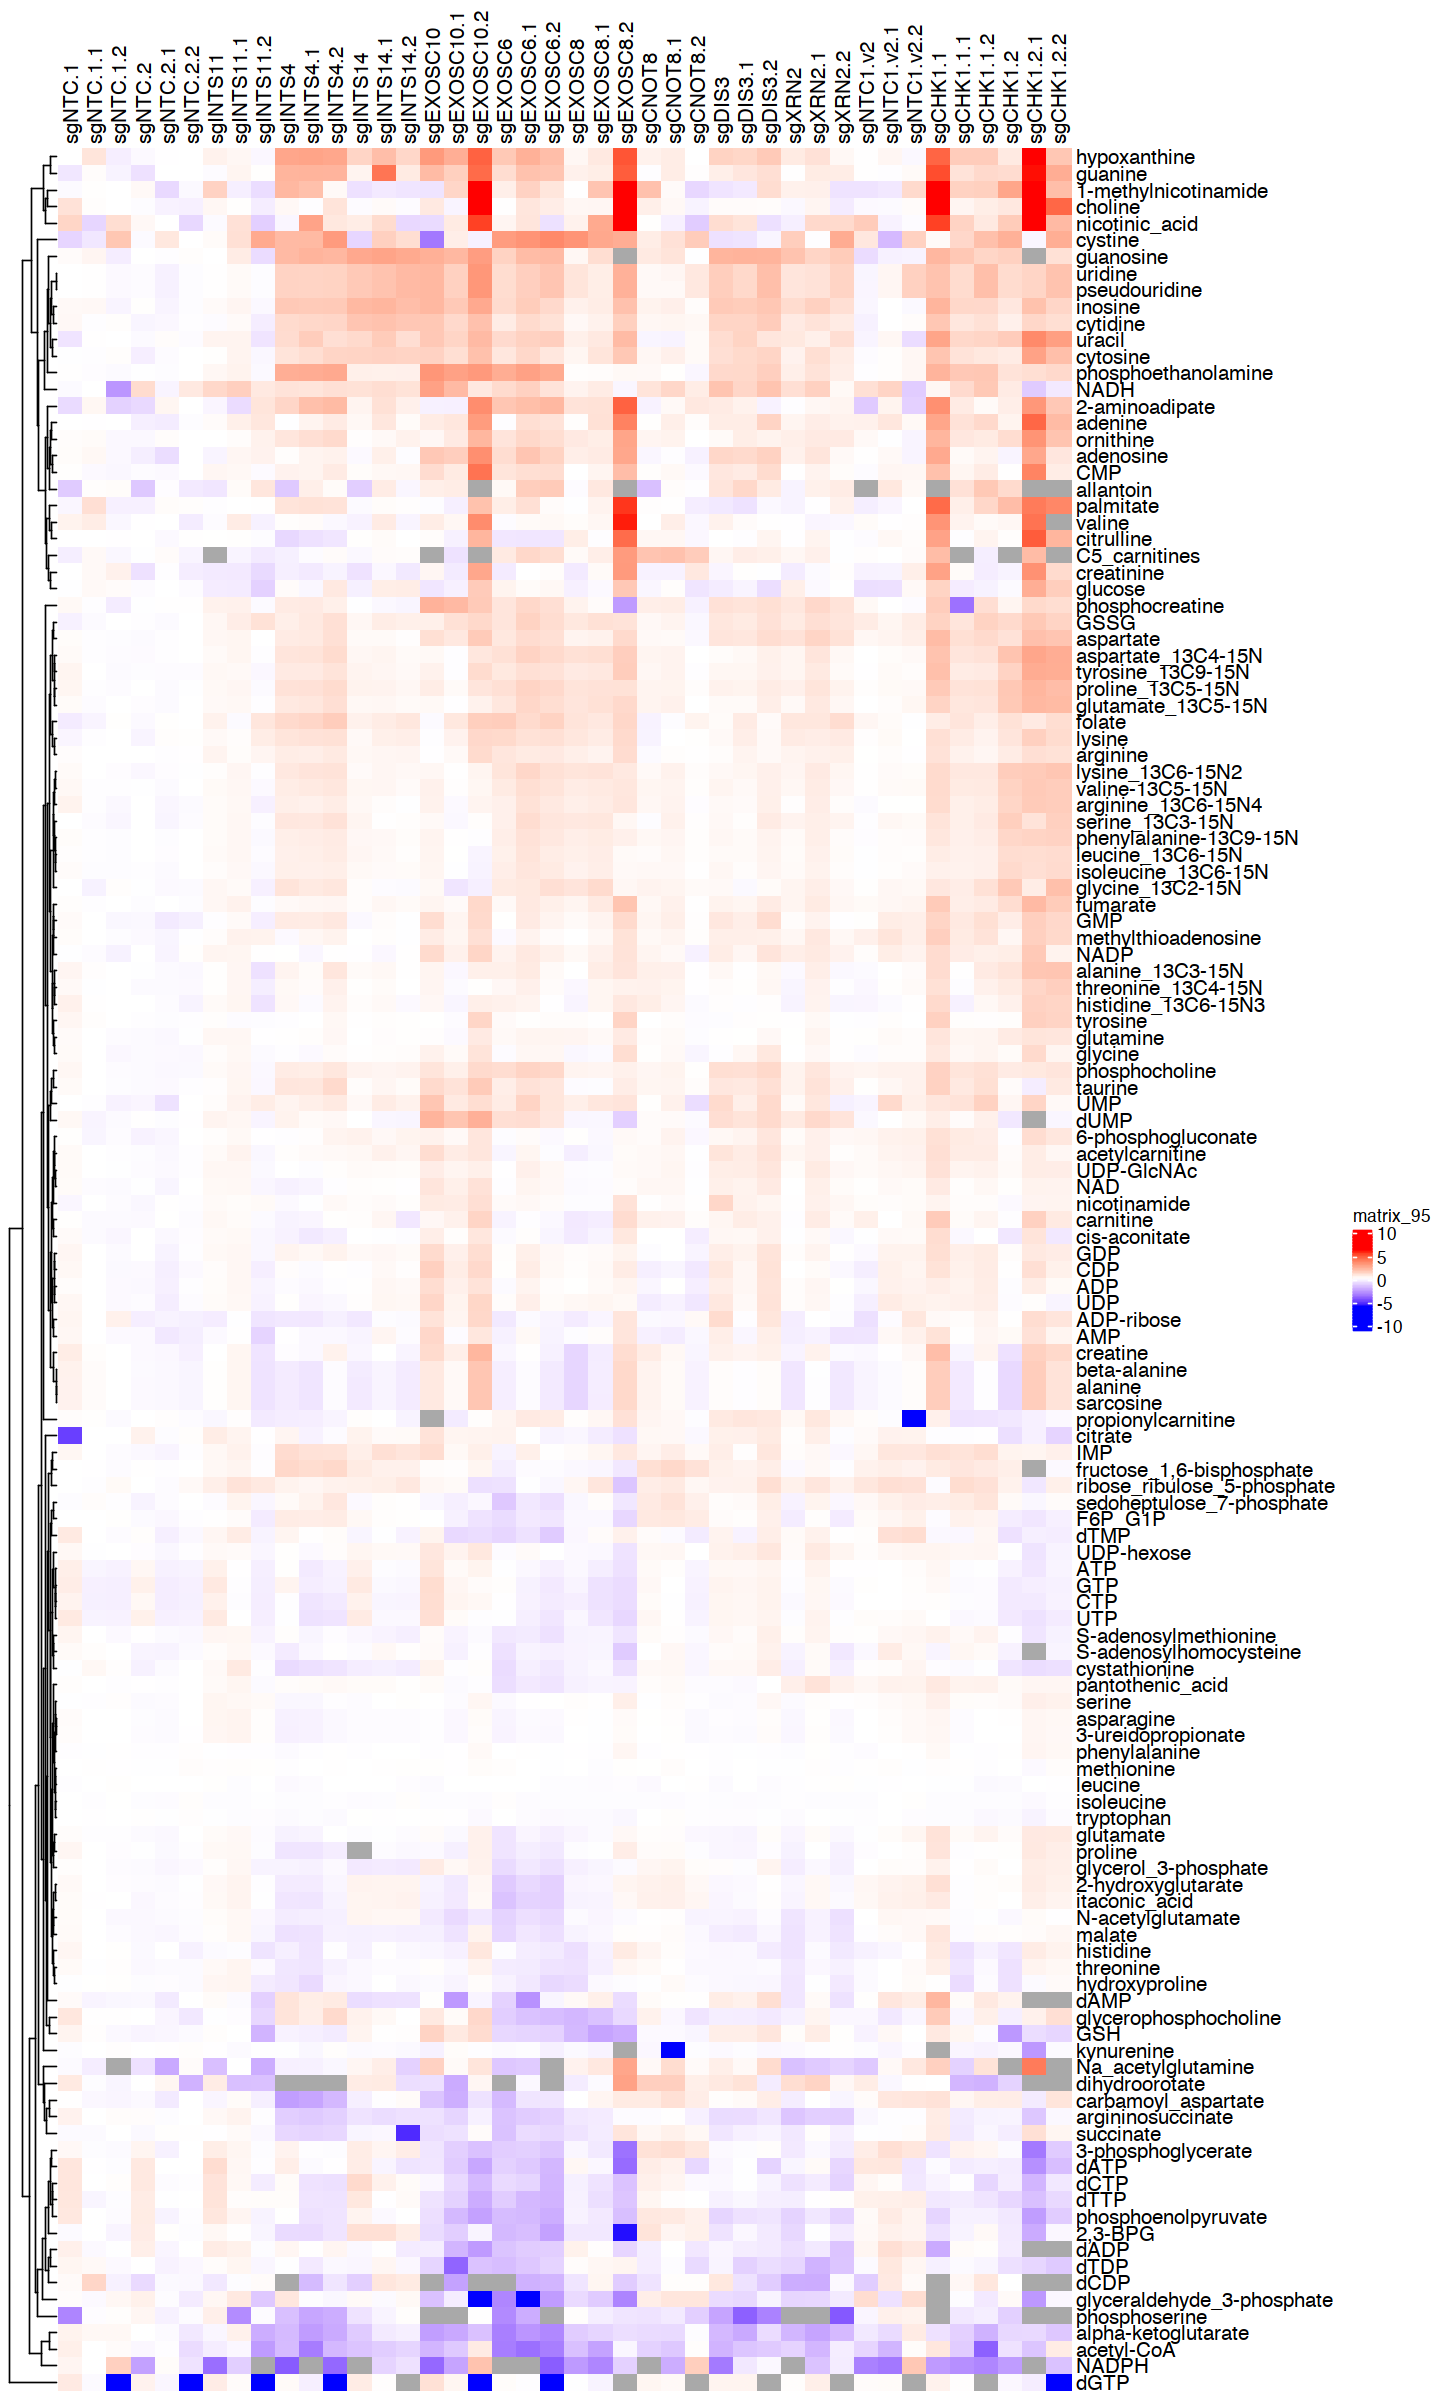

In [374]:
options(repr.plot.width=12,repr.plot.height=20)
col_fun = colorRamp2(c(-6, 0, 6), c("blue", "white", "red"))

pdf("./211120_bd289_heatmap_all.pdf", width=12, height=20)

Heatmap(data_zero_lfc, cluster_columns = FALSE,
        cluster_rows=TRUE,
        #row_km = 4, row_km_repeats=100,
        column_names_side = "top", col=col_fun,
        na_col="darkgray")
dev.off()



Heatmap(data_zero_lfc, cluster_columns = FALSE,
        cluster_rows=TRUE,
        #row_km = 4, row_km_repeats=100,
        column_names_side = "top", col=col_fun,
        na_col="darkgray")

## ER-Hoxa9

In [6]:
# removing metabolites with >20 NA values, and changing the remaining NA values to 0
er_data_zero = erhoxa9_data[,apply(erhoxa9_data,2,function(x) sum(is.na(x))) < 20]
er_data_zero = t(er_data_zero)
# second_to_last = dim(thp1_data_zero)[1]-1
# thp1_data_zero = rbind(thp1_data_zero[second_to_last:(second_to_last+1),], thp1_data_zero[1:(second_to_last-1),])
                        
#colnames(data_zero) = make.names(data_zero[1,], unique = TRUE)
dim(er_data_zero)
head(er_data_zero)

[1] 156  36

,BD13_63.3 DMSO rep 1,BD14_63.3 DMSO rep 2,BD15_63.3 DMSO rep 3,BD16_63.3 DMSO rep 4,BD17_63.3 BRQ 1uM rep 1,BD18_63.3 BRQ 1uM rep 2,BD19_63.3 BRQ 1uM rep 3,BD20_63.3 BRQ 1uM rep 4,BD21_63.3 HU 50uM rep 1,BD22_63.3 HU 50uM rep 2,⋯,BD39_63.3 G 1mM rep 3,BD40_63.3 G 1mM rep 4,BD41_63.3 U 1mM rep 1,BD42_63.3 U 1mM rep 2,BD43_63.3 U 1mM rep 3,BD44_63.3 U 1mM rep 4,BD45_63.3 T 250uM rep 1,BD46_63.3 T 250uM rep 2,BD47_63.3 T 250uM rep 3,BD48_63.3 T 250uM rep 4
palmitate,45803465.5,37736975.41,41841337.9,48793074.91,45223487.31,38279815.13,38510989.5,32150061.5,36102028.6,32020078.80,⋯,39882708.7,44199735.94,53120947.60,26360254.7,34992947.99,42253658.7,41844199.68,47058814.18,56626539.26,55872683.7
methylthioadenosine,79270146.3,75253893.23,81035019.3,92529954.19,27959408.17,23761282.68,35411432.3,36324340.9,47447351.1,48505691.29,⋯,22859883.5,31768062.62,86664767.74,65192927.5,102108694.24,63190013.6,22768946.15,22067266.57,25502490.06,31149343.1
N-acetylmethionine,433550.2,147586.43,799842.2,546811.39,86065.09,NA,422085.1,NA,1284806.1,973626.05,⋯,136493.8,44769.63,114733.66,303480.7,376079.21,163453.2,78502.38,73492.68,149881.64,145219.2
kynurenic_acid,NA,29906.59,NA,78485.67,NA,56901.92,109033.8,134014.9,NA,46109.22,⋯,NA,23340.56,29870.72,NA,41190.95,NA,NA,NA,63085.36,118233.3
nicotinamide,62983085.1,70505639.18,61927480.0,59651423.31,50137483.41,30891526.98,77342971.2,54120299.9,55283836.9,38736508.10,⋯,21653828.1,28542218.80,42728996.02,45230600.9,52171263.12,28333574.4,17304438.84,29552033.70,27439055.92,35253197.5
C5_carnitines,2470735.3,2702855.99,2416590.4,2260596.89,69995.27,NA,NA,212480.7,205700.9,NA,⋯,NA,860699.87,2187153.71,1623687.0,2213721.22,1610902.9,NA,176797.11,NA,353100.2


In [7]:
# normalize for extraction efficiency -- 15N 
# std_rows = data_zero_mat[grepl('valine-13C5-15N', rownames(data_zero_mat)),]
# std_norm_vals = std_rows

std_rows = er_data_zero[grepl('15N', rownames(er_data_zero)),]
std_rows = std_rows[!(rownames(std_rows) %in% c("methionine_13C6-15N")),]  # this was NA in some of the samples
std_norm_vals = std_rows/apply(std_rows[,1:4],1,median, na.rm=T)
std_norm_vals = apply(std_norm_vals,2,median, na.rm=T)

er_data_zero_norm = t(t(er_data_zero) / std_norm_vals)
er_data_zero_norm2 = er_data_zero_norm
# options(repr.plot.width=15,repr.plot.height=5)
# boxplot(std_rows/std_rows[,1])
# abline(h=1)

# std_rows = data_zero_mat_norm[grepl('15N', rownames(data_zero_mat)),]
# boxplot(std_rows/std_rows[,1])
# abline(h=1)



In [8]:
# normalize for BCAAs 
bcaa_rows = er_data_zero_norm[c("lysine", "valine", "isoleucine", "leucine", "tryptophan"),]
#bcaa_rows = data_zero_norm[c("lysine", "valine", "isoleucine"),]
bcaa_norm_vals = bcaa_rows/apply(bcaa_rows[,c(1:6, 34:36)],1,median)
bcaa_norm_vals = apply(bcaa_norm_vals,2,median, na.rm=T)


ERROR: Error in t(thp1_data_zero_norm): object 'thp1_data_zero_norm' not found


In [9]:
# log fold change compared to NTCs 

er_data_zero_norm2[er_data_zero_norm2 == 0] = NA
er_data_zero_lfc = log2(er_data_zero_norm2/apply(er_data_zero_norm2[,1:4],1,median, na.rm=T))
#data_zero_lfc = log2(data_zero_mat_norm2/data_zero_mat_norm2[,2])  # normalize by #2

er_data_zero_lfc[is.infinite(er_data_zero_lfc)] = NA
#data_zero_lfc[is.nan(data_zero_lfc)] = NA
er_data_zero_lfc = er_data_zero_lfc[order(rownames(er_data_zero_lfc)),]
er_data_zero_lfc = er_data_zero_lfc[apply(er_data_zero_lfc,1,function(x) sum(is.na(x))) < 20,]

var_vals = apply(er_data_zero_lfc,1,function(x) var(x, na.rm=T))

                 

pdf 
  2

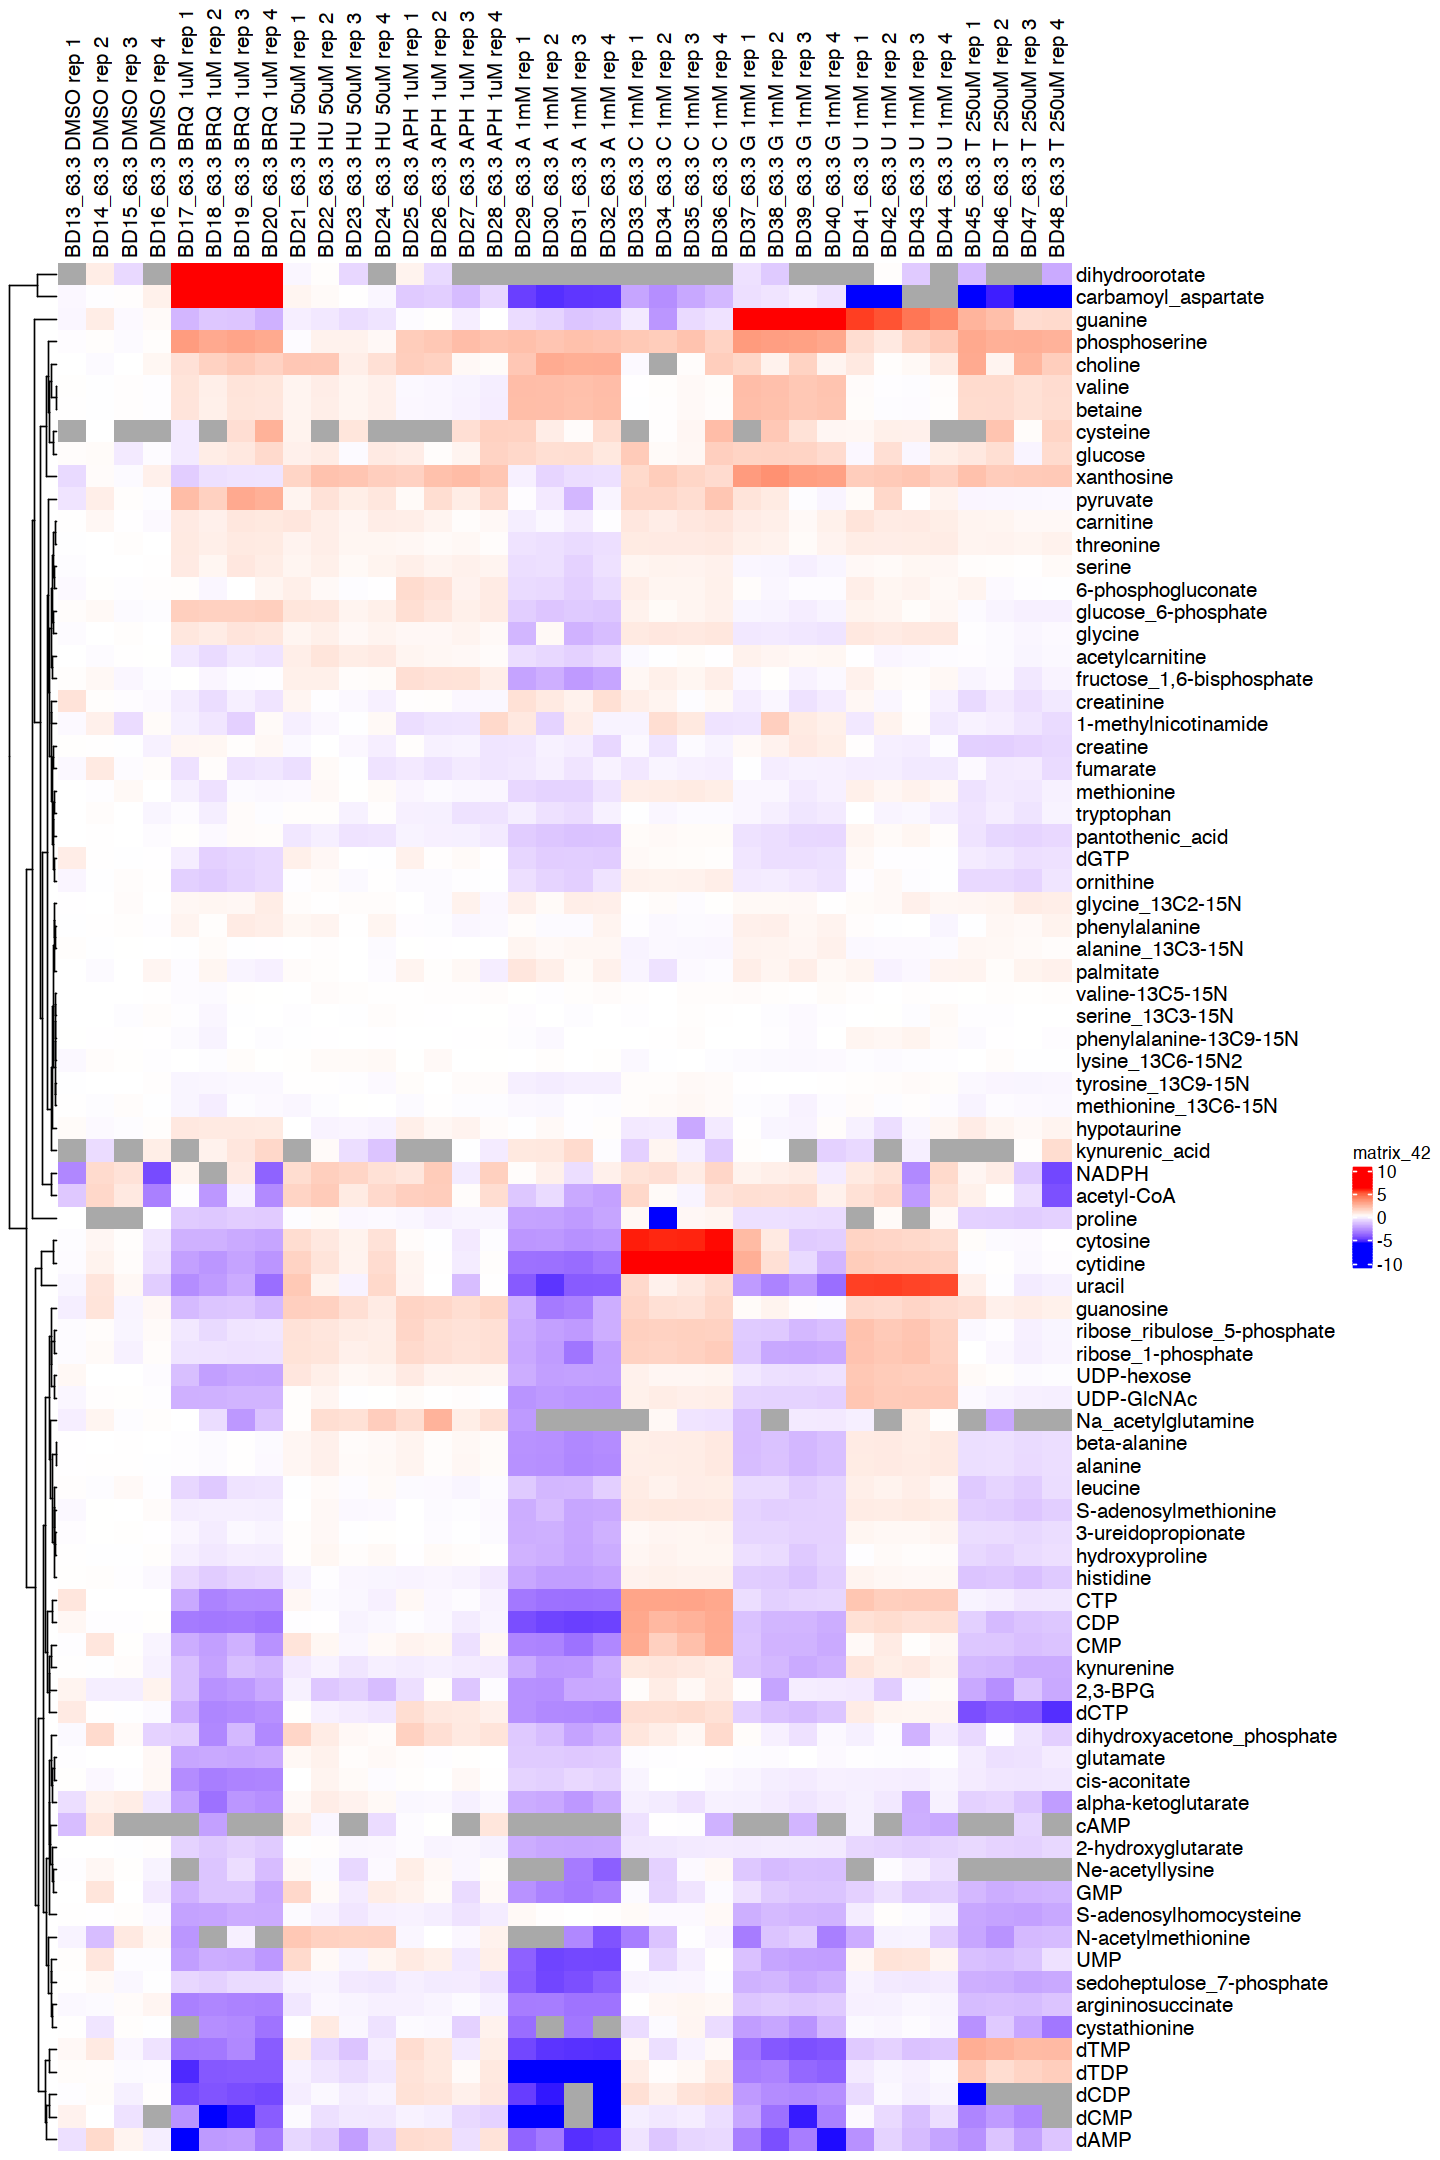

In [117]:
options(repr.plot.width=12,repr.plot.height=18)
col_fun = colorRamp2(c(-6, 0, 6), c("blue", "white", "red"))

er_data_zero_lfc_highvar = er_data_zero_lfc[var_vals>0.5,]

pdf("./220119_bd295_erhoxa9_highvar_heatmap.pdf", width=12, height=18)

d = Heatmap(er_data_zero_lfc_highvar, cluster_columns = FALSE,
        cluster_rows=TRUE,
        #row_km = 4, row_km_repeats=100,
        column_names_side = "top", col=col_fun,
        na_col="darkgray")

dev.off()
d

## Response ratios

In [11]:
rrdata <- list()
sheetlist <- excel_sheets(path="./220114_processed_Long.XLS")

for (metab in sheetlist[1:(length(sheetlist)-2)]){
    tempdf <- read_excel(path="./220114_processed_Long.XLS", sheet = metab, skip=4)
    #print(tempdf["Area"])
    rrdata[[metab]] <- tempdf %>% pull("Response Ratio")
}

rrdata = as.data.frame(rrdata)
rrdata = rrdata[2:49,]
print(dim(rrdata))

[1]  48 180


In [13]:
colnames(rrdata) = sheetlist[1:(length(sheetlist)-2)]
rrdata[rrdata == "NF"] = NA
rrdata[] <- lapply(rrdata, function(x) as.numeric(x))
row.names(rrdata) = samples[2:49]
                   
thp1_rrdata = rrdata[1:12,]
erhoxa9_rrdata = rrdata[13:48,]
    
head(thp1_rrdata)           

Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning message in FUN(X[[i]], ...):
“NAs introduced by coercion”
Warning me

,palmitate,alpha-lipoic_acid,N-acetylphenylalanine,methylthioadenosine,N-acetylmethionine,phenylacetyl_glutamine,kynurenic_acid,nicotinamide,C5_carnitines,butyryl_carnitine,⋯,citrate,cis-aconitate,"fructose_1,6-bisphosphate",PRPP,lysine,lysine_13C6-15N2,SAICAR,GTP,arginine,arginine_13C6-15N4
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
BD01_THP-1 DMSO rep 1,0.05680152,NA,1.164629e-04,0.03734060,0.0031052956,NA,6.562336e-05,0.09250813,0.03894214,0.3613443,⋯,64.54121,2.9470673,0.2396367,0.0560200441,0.3734322,NA,0.04604507,2.614427,3.427316,NA
BD02_THP-1 DMSO rep 2,0.81376219,NA,1.278703e-03,0.07516951,0.0005901344,NA,2.312206e-03,0.07951563,0.08998234,0.5640966,⋯,25.99883,3.7181806,0.1021048,NA,0.5226132,NA,0.02053380,0.758825,3.768881,NA
BD03_THP-1 DMSO rep 3,0.06246131,NA,8.780950e-05,0.03802449,0.0025003862,NA,1.917546e-04,0.06456593,0.03237240,0.2877986,⋯,51.40263,2.5716783,0.2248527,0.0504563440,0.3879860,NA,0.03391594,1.707787,3.350682,NA
BD04_THP-1 DMSO rep 4,0.05610298,NA,6.336768e-05,0.03756920,0.0024420280,NA,2.531454e-04,0.07207594,0.03196278,0.3229808,⋯,50.64241,2.7637576,0.2261066,0.0004201143,0.4342181,NA,0.03082761,1.578446,3.650655,NA
BD05_THP-1 BRQ 500nM rep 1,0.06543667,NA,5.919611e-05,0.02422029,0.0009152866,NA,4.518097e-04,0.16286784,0.01651852,0.2342126,⋯,27.31279,0.8292806,0.3118320,NA,0.6717630,NA,NA,2.061212,4.381995,NA
BD06_THP-1 BRQ 500nM rep 2,0.05758699,NA,NA,0.02799138,0.0006843743,NA,3.646100e-04,0.13977716,0.01835732,0.2710581,⋯,14.11837,0.6389456,0.2754340,NA,0.7068236,NA,NA,1.029578,4.053547,NA


### THP-1 RR data

In [89]:
# removing metabolites with >5 NA values, and changing the remaining NA values to 0
thp1_rrdata_zero = thp1_rrdata[,apply(thp1_rrdata,2,function(x) sum(is.na(x))) < 5]

thp1_rrdata_zero = t(thp1_rrdata_zero)
# second_to_last = dim(rrdata_zero)[1]-1
# rrdata_zero = rbind(rrdata_zero[second_to_last:(second_to_last+1),], rrdata_zero[1:(second_to_last-1),])
thp1_rrdata_zero = thp1_rrdata_zero[apply(thp1_rrdata_zero,1,function(x) sum(x == 0, na.rm=T)) < 10,]
thp1_rrdata_zero = thp1_rrdata_zero[!is.na(rownames(thp1_rrdata_zero)),]
dim(thp1_rrdata_zero)
head(thp1_rrdata_zero)
             

[1] 137  12

,BD01_THP-1 DMSO rep 1,BD02_THP-1 DMSO rep 2,BD03_THP-1 DMSO rep 3,BD04_THP-1 DMSO rep 4,BD05_THP-1 BRQ 500nM rep 1,BD06_THP-1 BRQ 500nM rep 2,BD07_THP-1 BRQ 500nM rep 3,BD08_THP-1 BRQ 500nM rep 4,BD09_THP-1 HU 100uM rep 1,BD10_THP-1 HU 100uM rep 2,BD11_THP-1 HU 100uM rep 3,BD12_THP-1 HU 100uM rep 4
palmitate,5.680152e-02,0.8137621916,0.0624613124,5.610298e-02,6.543667e-02,0.0575869869,4.836482e-02,5.028029e-02,0.05019126,0.3543428198,3.050850e-02,0.0288590579
N-acetylphenylalanine,1.164629e-04,0.0012787031,0.0000878095,6.336768e-05,5.919611e-05,NA,3.894894e-05,6.461097e-05,NA,0.0005993616,5.615777e-05,0.0002496563
methylthioadenosine,3.734060e-02,0.0751695072,0.0380244892,3.756920e-02,2.422029e-02,0.0279913757,2.601109e-02,1.925936e-02,0.03848925,0.0744867267,4.351505e-02,0.0383866137
N-acetylmethionine,3.105296e-03,0.0005901344,0.0025003862,2.442028e-03,9.152866e-04,0.0006843743,6.450908e-04,1.660270e-03,0.02263216,0.0181121405,2.150720e-02,0.0180605710
kynurenic_acid,6.562336e-05,0.0023122058,0.0001917546,2.531454e-04,4.518097e-04,0.0003646100,4.120583e-04,4.208066e-04,NA,0.0002763479,4.680678e-04,NA
nicotinamide,9.250813e-02,0.0795156319,0.0645659274,7.207594e-02,1.628678e-01,0.1397771622,1.576574e-01,1.814533e-01,0.10579528,0.1356193354,1.561141e-01,0.0969865298


In [106]:
# normalize for BCAAs 
rr_bcaa_rows = thp1_rrdata_zero[c("lysine", "valine", "isoleucine", "leucine", "tryptophan"),]
#rr_bcaa_rows = rrdata_zero[c("lysine", "valine", "isoleucine"),]
thp1_rr_bcaa_norm_vals = rr_bcaa_rows/apply(rr_bcaa_rows[,c(1,3,4)],1,median, na.rm=T)
thp1_rr_bcaa_norm_vals = apply(thp1_rr_bcaa_norm_vals,2,median, na.rm=T)

thp1_rrdata_zero_norm2 = t(t(thp1_rrdata_zero) / thp1_rr_bcaa_norm_vals)


# don't normalize for BCAAs
#thp1_rrdata_zero_norm2 = thp1_rrdata_zero

In [107]:
# log fold change compared to NTCs 


thp1_rrdata_zero_norm2[thp1_rrdata_zero_norm2 == 0] = NA
thp1_rr_data_zero_lfc = log2(thp1_rrdata_zero_norm2/apply(thp1_rrdata_zero_norm2[,c(1,3,4)],1,median, na.rm=T))

#rr_data_zero_lfc[is.infinite(rr_data_zero_lfc)] = NA
thp1_rr_data_zero_lfc = thp1_rr_data_zero_lfc[order(rownames(thp1_rr_data_zero_lfc)),]
thp1_rr_data_zero_lfc = thp1_rr_data_zero_lfc[apply(thp1_rr_data_zero_lfc,1,function(x) sum(is.na(x))) < 5,]

var_vals = apply(thp1_rr_data_zero_lfc,1,function(x) var(x, na.rm=T))

                 

pdf 
  2

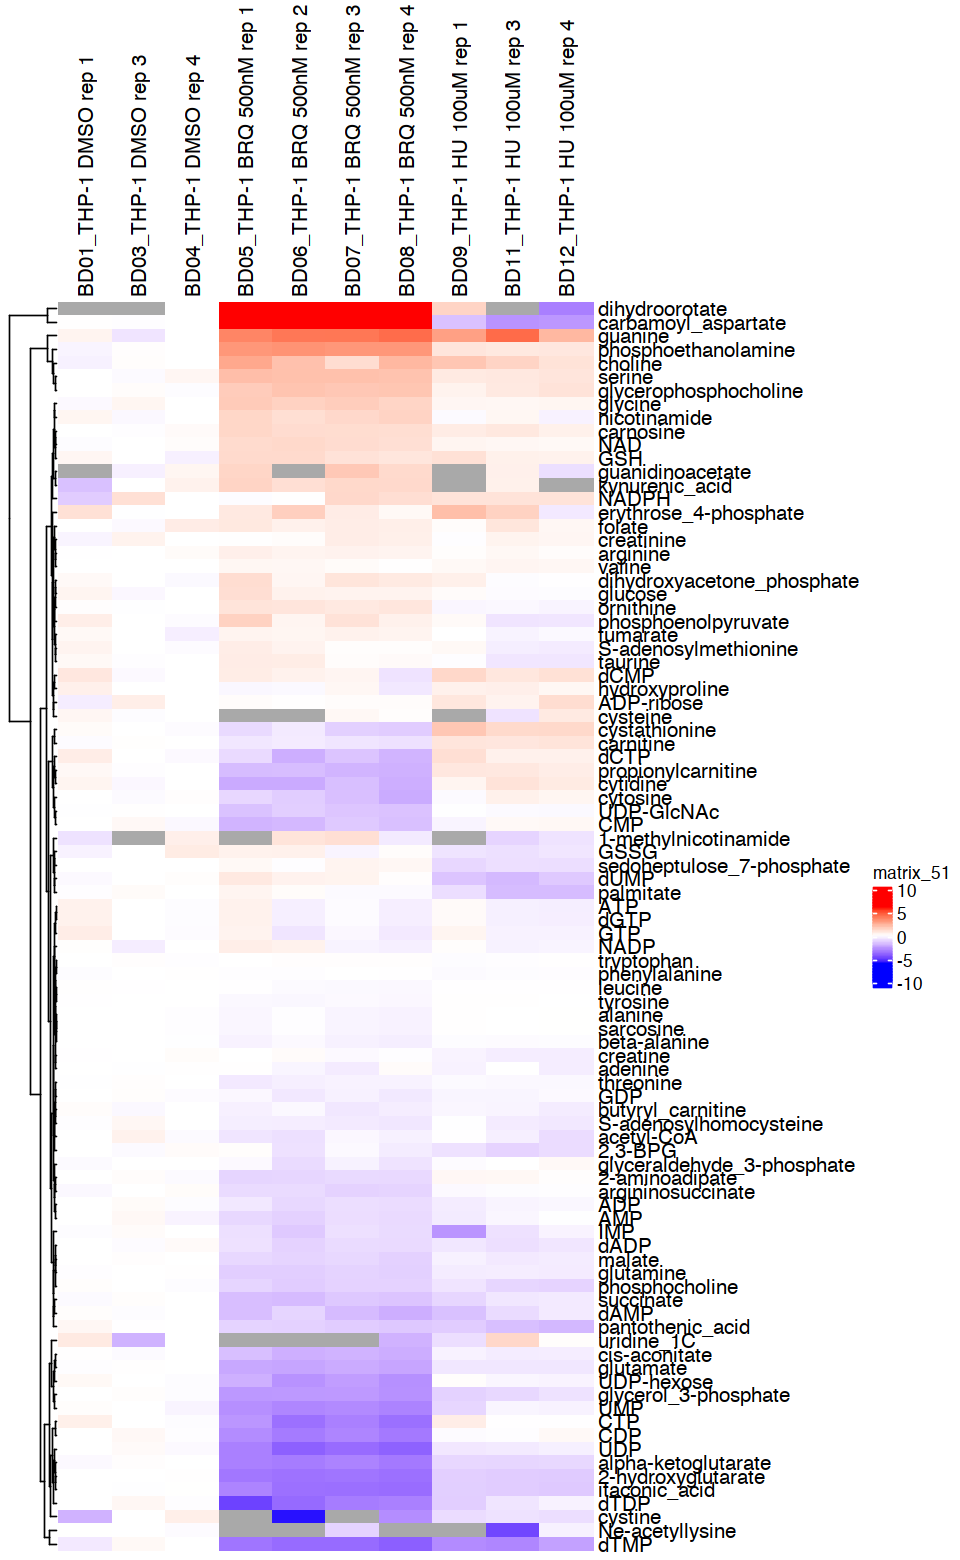

In [177]:
options(repr.plot.width=8,repr.plot.height=13)
col_fun = colorRamp2(c(-6, 0, 6), c("blue", "white", "red"))

thp1_rr_data_zero_lfc_highvar = thp1_rr_data_zero_lfc[var_vals>0.5,]

pdf("./220114_bd295_thp1_highvar_istd.pdf", width=8, height=10)

d = Heatmap(thp1_rr_data_zero_lfc_highvar[,c(1,3:9,11:12)], cluster_columns = FALSE,
        cluster_rows=TRUE,
        #row_km = 4, row_km_repeats=100,
        column_names_side = "top", col=col_fun,
        na_col="darkgray")
d
dev.off()

d

pdf 
  2

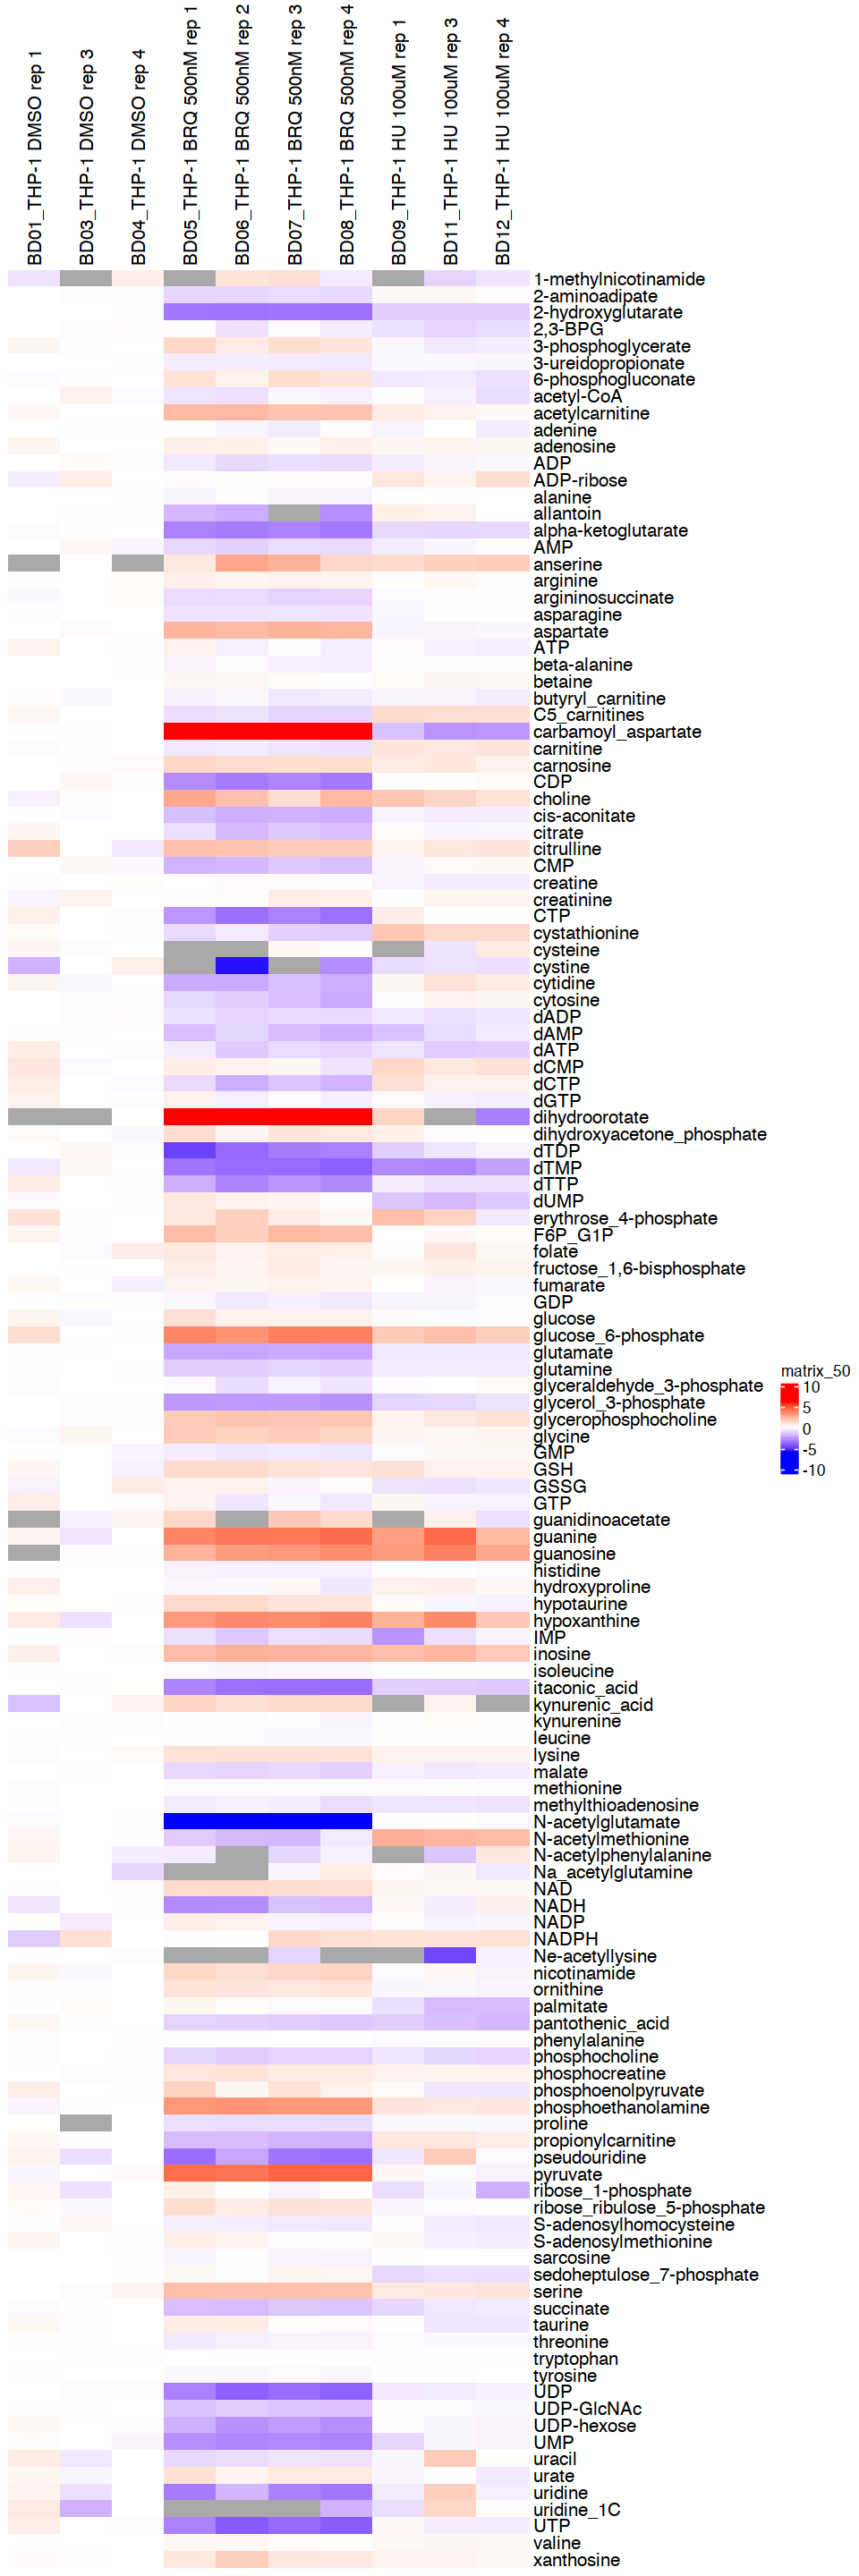

In [176]:
options(repr.plot.width=8,repr.plot.height=24)
col_fun = colorRamp2(c(-6, 0, 6), c("blue", "white", "red"))

pdf("./220114_bd295_thp1_all_istd.pdf", width=8, height=24)


d = Heatmap(thp1_rr_data_zero_lfc[,c(1,3:9,11:12)], cluster_columns = FALSE,
        cluster_rows=FALSE,
        #row_km = 4, row_km_repeats=100,
        column_names_side = "top", col=col_fun,
        na_col="darkgray")
d
dev.off()

d

In [172]:
write.csv(thp1_rr_data_zero_lfc[,c(1,3:9,11:12)], "220119_bd295_thp1_rr_lfc.csv", quote=F)

### ER-Hoxa9 RR data

In [14]:
# removing metabolites with >5 NA values, and changing the remaining NA values to 0
er_rrdata_zero = erhoxa9_rrdata[,apply(erhoxa9_rrdata,2,function(x) sum(is.na(x))) < 20]

er_rrdata_zero = t(er_rrdata_zero)
# second_to_last = dim(rrdata_zero)[1]-1
# rrdata_zero = rbind(rrdata_zero[second_to_last:(second_to_last+1),], rrdata_zero[1:(second_to_last-1),])
er_rrdata_zero = er_rrdata_zero[apply(er_rrdata_zero,1,function(x) sum(x == 0, na.rm=T)) < 10,]
er_rrdata_zero = er_rrdata_zero[!is.na(rownames(er_rrdata_zero)),]
dim(er_rrdata_zero)
head(er_rrdata_zero)
             

[1] 140  36

,BD13_63.3 DMSO rep 1,BD14_63.3 DMSO rep 2,BD15_63.3 DMSO rep 3,BD16_63.3 DMSO rep 4,BD17_63.3 BRQ 1uM rep 1,BD18_63.3 BRQ 1uM rep 2,BD19_63.3 BRQ 1uM rep 3,BD20_63.3 BRQ 1uM rep 4,BD21_63.3 HU 50uM rep 1,BD22_63.3 HU 50uM rep 2,⋯,BD39_63.3 G 1mM rep 3,BD40_63.3 G 1mM rep 4,BD41_63.3 U 1mM rep 1,BD42_63.3 U 1mM rep 2,BD43_63.3 U 1mM rep 3,BD44_63.3 U 1mM rep 4,BD45_63.3 T 250uM rep 1,BD46_63.3 T 250uM rep 2,BD47_63.3 T 250uM rep 3,BD48_63.3 T 250uM rep 4
palmitate,0.055364203,5.171219e-02,0.054238071,0.0695487639,0.0561372840,0.0839963110,0.0454235364,0.0451938991,0.0621214793,5.875998e-02,⋯,0.0886431741,6.392890e-02,5.535498e-02,0.037623290,3.800910e-02,0.0642458551,0.0775695728,0.0604041100,7.161353e-02,0.0792738786
methylthioadenosine,0.095816516,1.031228e-01,0.105044039,0.1318905182,0.0347068599,0.0521387077,0.0417676229,0.0510617561,0.0816436016,8.901269e-02,⋯,0.0508083002,4.594818e-02,9.030951e-02,0.093048131,1.109098e-01,0.0960791699,0.0422084169,0.0283252696,3.225207e-02,0.0441956441
N-acetylmethionine,0.001070135,4.385525e-04,0.002046086,0.0016316973,0.0002434346,NA,0.0010974893,NA,0.0052072430,3.856410e-03,⋯,0.0007125336,1.438085e-04,2.834399e-04,0.001124634,1.040868e-03,0.0006009365,0.0003359992,0.0002079116,4.299647e-04,0.0004629024
kynurenic_acid,NA,4.098196e-05,NA,0.0001118721,NA,0.0001248583,0.0001286048,0.0001883871,NA,8.461494e-05,⋯,NA,3.375894e-05,3.112695e-05,NA,4.474133e-05,NA,NA,NA,7.978176e-05,0.0001677531
nicotinamide,0.076129793,9.661614e-02,0.080275327,0.0850260567,0.0622371761,0.0677844002,0.0912256816,0.0760778444,0.0951279988,7.108529e-02,⋯,0.0481277256,4.128243e-02,4.452599e-02,0.064556433,5.666806e-02,0.0430806413,0.0320784706,0.0379326238,3.470118e-02,0.0500183187
C5_carnitines,0.005336742,7.013824e-03,0.005345187,0.0058744871,0.0001964030,NA,NA,0.0006169916,0.0006998512,NA,⋯,NA,2.706826e-03,4.877672e-03,0.004919289,4.890115e-03,0.0048842496,NA,0.0004794350,NA,0.0010558014


In [15]:
# normalize for BCAAs 
rr_bcaa_rows = er_rrdata_zero[c("lysine", "valine", "isoleucine", "leucine", "tryptophan"),]
#rr_bcaa_rows = rrdata_zero[c("lysine", "valine", "isoleucine"),]
er_rr_bcaa_norm_vals = rr_bcaa_rows/apply(rr_bcaa_rows[,1:4],1,median, na.rm=T)
er_rr_bcaa_norm_vals = apply(er_rr_bcaa_norm_vals,2,median, na.rm=T)

er_rrdata_zero_norm2 = t(t(er_rrdata_zero) / er_rr_bcaa_norm_vals)


# don't normalize for BCAAs
#thp1_rrdata_zero_norm2 = thp1_rrdata_zero

pdf 
  2

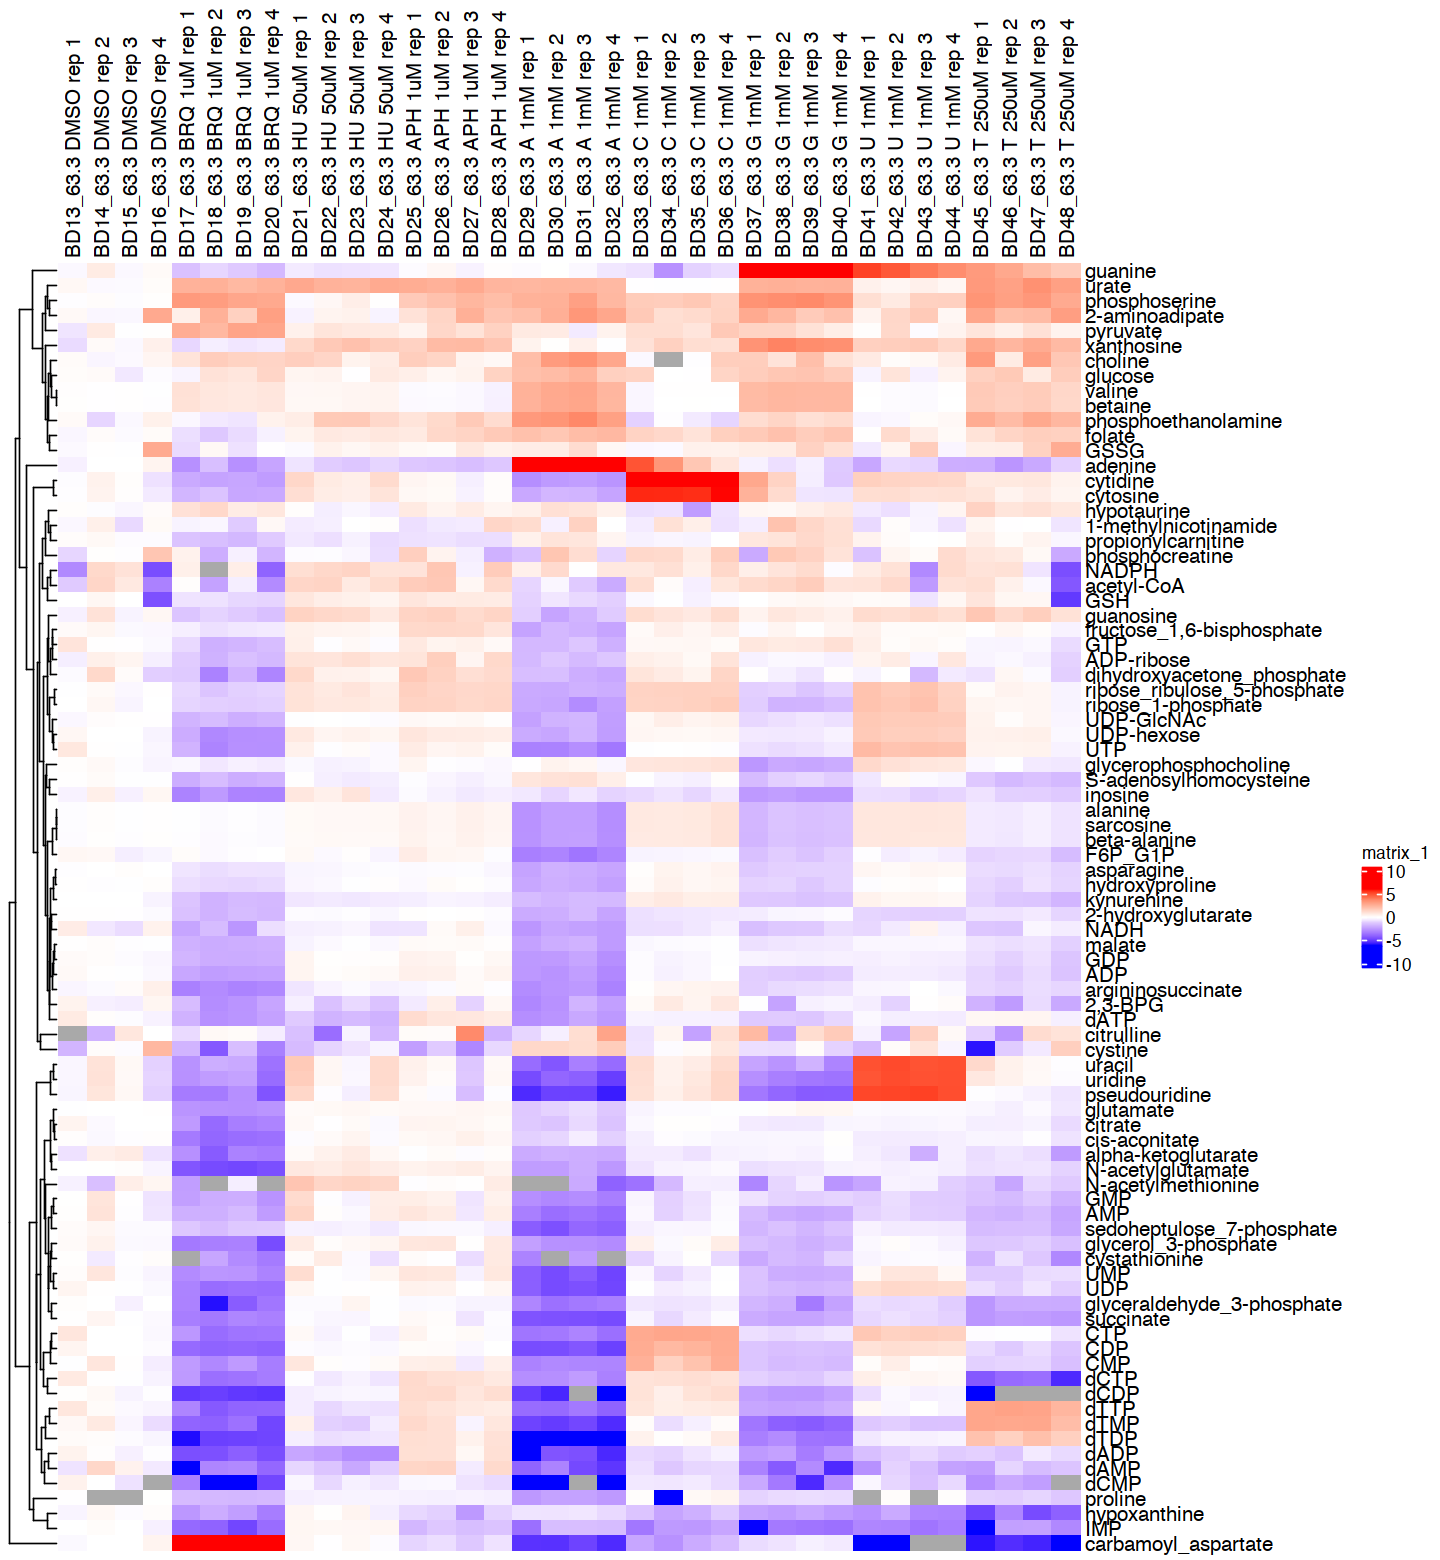

In [16]:
# log fold change compared to NTCs 


er_rrdata_zero_norm2[er_rrdata_zero_norm2 == 0] = NA
er_rr_data_zero_lfc = log2(er_rrdata_zero_norm2/apply(er_rrdata_zero_norm2[,1:4],1,median, na.rm=T))

#rr_data_zero_lfc[is.infinite(rr_data_zero_lfc)] = NA
er_rr_data_zero_lfc = er_rr_data_zero_lfc[order(rownames(er_rr_data_zero_lfc)),]
er_rr_data_zero_lfc = er_rr_data_zero_lfc[apply(er_rr_data_zero_lfc,1,function(x) sum(is.na(x))) < 5,]

var_vals = apply(er_rr_data_zero_lfc,1,function(x) var(x, na.rm=T))
                 
options(repr.plot.width=12,repr.plot.height=13)
col_fun = colorRamp2(c(-6, 0, 6), c("blue", "white", "red"))

er_rr_data_zero_lfc_highvar = er_rr_data_zero_lfc[var_vals>0.5,]

pdf("./220114_bd295_erhoxa9_highvar_istd.pdf", width=12, height=13)

d = Heatmap(er_rr_data_zero_lfc_highvar, cluster_columns = FALSE,
        cluster_rows=TRUE,
        #row_km = 4, row_km_repeats=100,
        column_names_side = "top", col=col_fun,
        na_col="darkgray")
d
dev.off()

d                 

null device 
          1

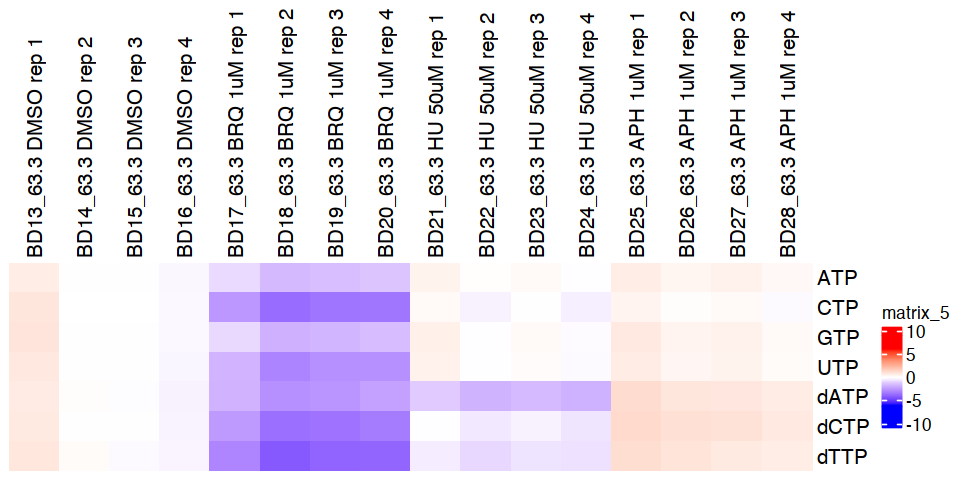

In [22]:
z = er_rr_data_zero_lfc[c("ATP", "CTP", "GTP", "UTP", "dATP", "dCTP", "dTTP"),1:16]

options(repr.plot.width=8,repr.plot.height=4)
d = Heatmap(z, cluster_columns = FALSE,
        cluster_rows=FALSE,
        #row_km = 4, row_km_repeats=100,
        column_names_side = "top", col=col_fun,
        na_col="darkgray")
d
dev.off()

pdf 
  2

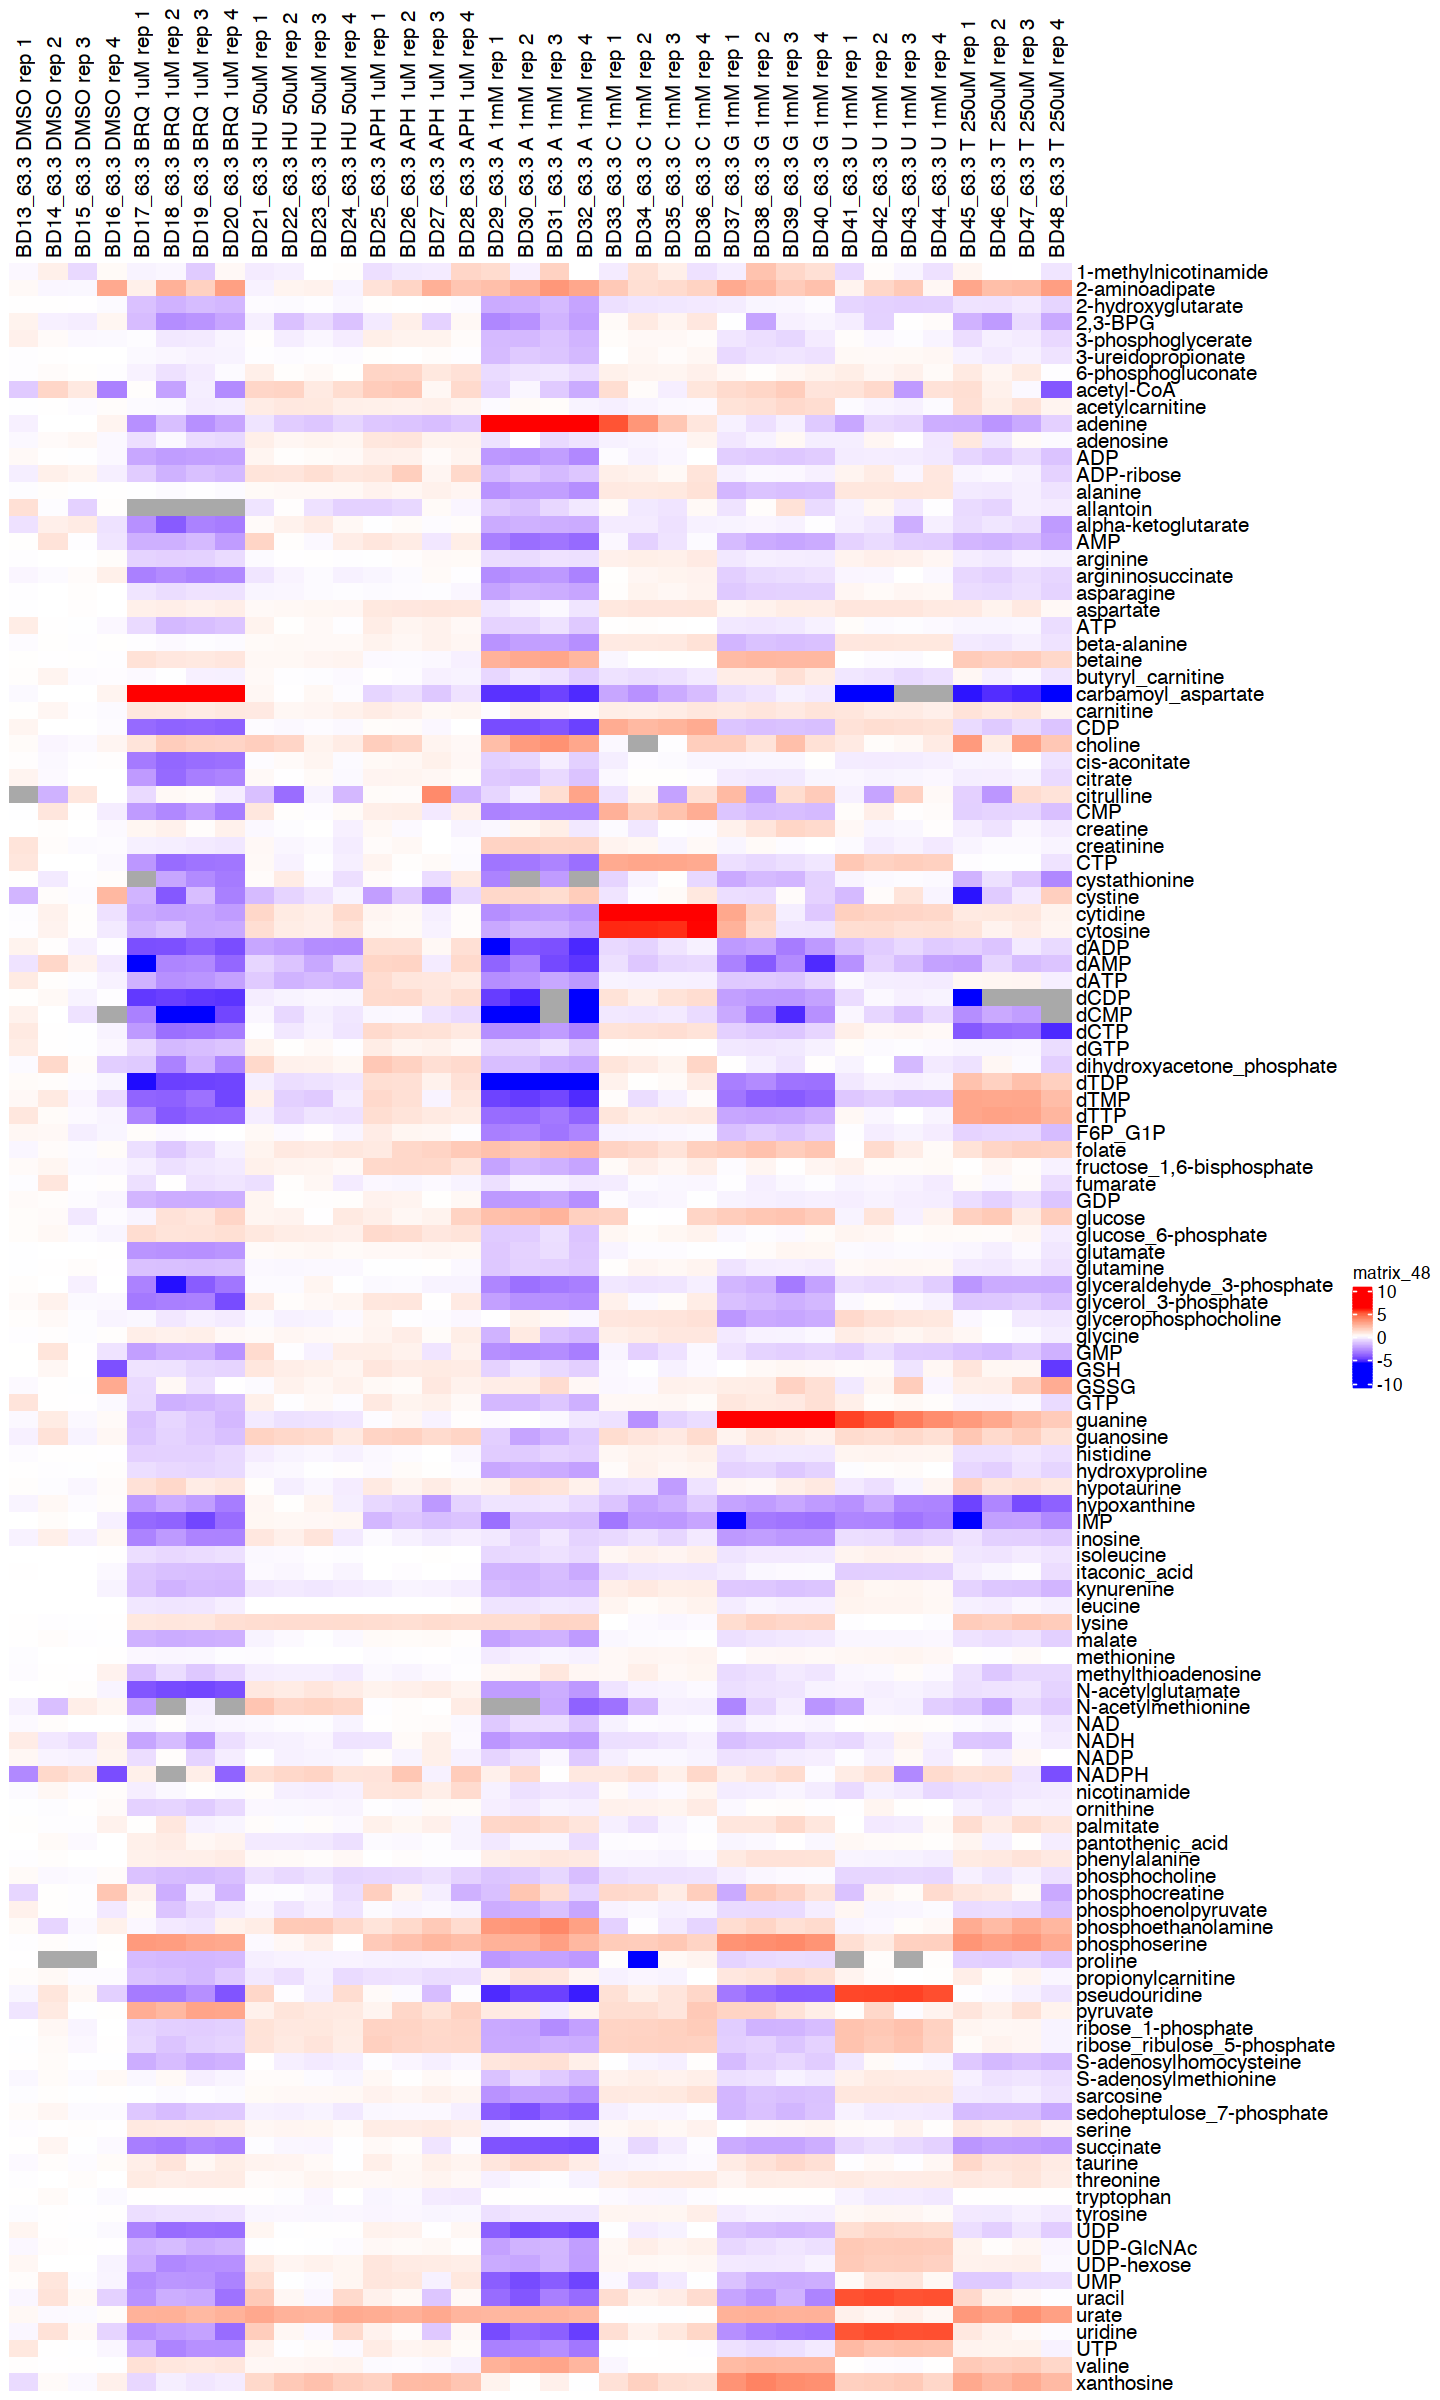

In [174]:
options(repr.plot.width=12,repr.plot.height=20)
col_fun = colorRamp2(c(-6, 0, 6), c("blue", "white", "red"))

pdf("./220114_bd295_erhoxa9_all_istd.pdf", width=12, height=20)


d = Heatmap(er_rr_data_zero_lfc, cluster_columns = FALSE,
        cluster_rows=FALSE,
        #row_km = 4, row_km_repeats=100,
        column_names_side = "top", col=col_fun,
        na_col="darkgray")
d
dev.off()

d

In [173]:
write.csv(er_rr_data_zero_lfc, "220119_bd295_erhoxa9_rr_lfc.csv", quote=F)

## Plot selected metabolites

In [131]:
er_sample_to_tx = as.data.frame(cbind(colnames(er_rrdata_zero), sapply(colnames(er_rrdata_zero), 
                                                             function(x) unlist(strsplit(gsub(' ', '_', x), 
                                                                                         split='_', fixed=T))[3])))
colnames(er_sample_to_tx) = c("sample", "tx")
head(er_sample_to_tx)

,sample,tx
,<chr>,<chr>
BD13_63.3 DMSO rep 1,BD13_63.3 DMSO rep 1,DMSO
BD14_63.3 DMSO rep 2,BD14_63.3 DMSO rep 2,DMSO
BD15_63.3 DMSO rep 3,BD15_63.3 DMSO rep 3,DMSO
BD16_63.3 DMSO rep 4,BD16_63.3 DMSO rep 4,DMSO
BD17_63.3 BRQ 1uM rep 1,BD17_63.3 BRQ 1uM rep 1,BRQ
BD18_63.3 BRQ 1uM rep 2,BD18_63.3 BRQ 1uM rep 2,BRQ


In [160]:
plot_vals = function(metabs, xax, conds, w=8, h=14, s=1) {
    df = melt(er_rr_data_zero_lfc[metabs,])
    df = merge(df, er_sample_to_tx, by.x = "Var2", by.y="sample")
    df = subset(df, tx %in% conds)
    df$tx = factor(df$tx, levels=conds)
    #print(head(df))

    options(repr.plot.width=w, repr.plot.height=h)
    p = ggplot(data=df, aes(x= !!sym(xax), y=value)) + geom_boxplot() + geom_point(size=s) +  theme_bw() +
                theme(axis.text.x = element_text(angle = 45, hjust=1)) + 
                ylab("log2FC") + geom_hline(yintercept=0, color="grey")
    return(p)
}

Warning message:
“Removed 3 rows containing non-finite values (stat_boxplot).”
Warning message:
“Removed 3 rows containing missing values (geom_point).”


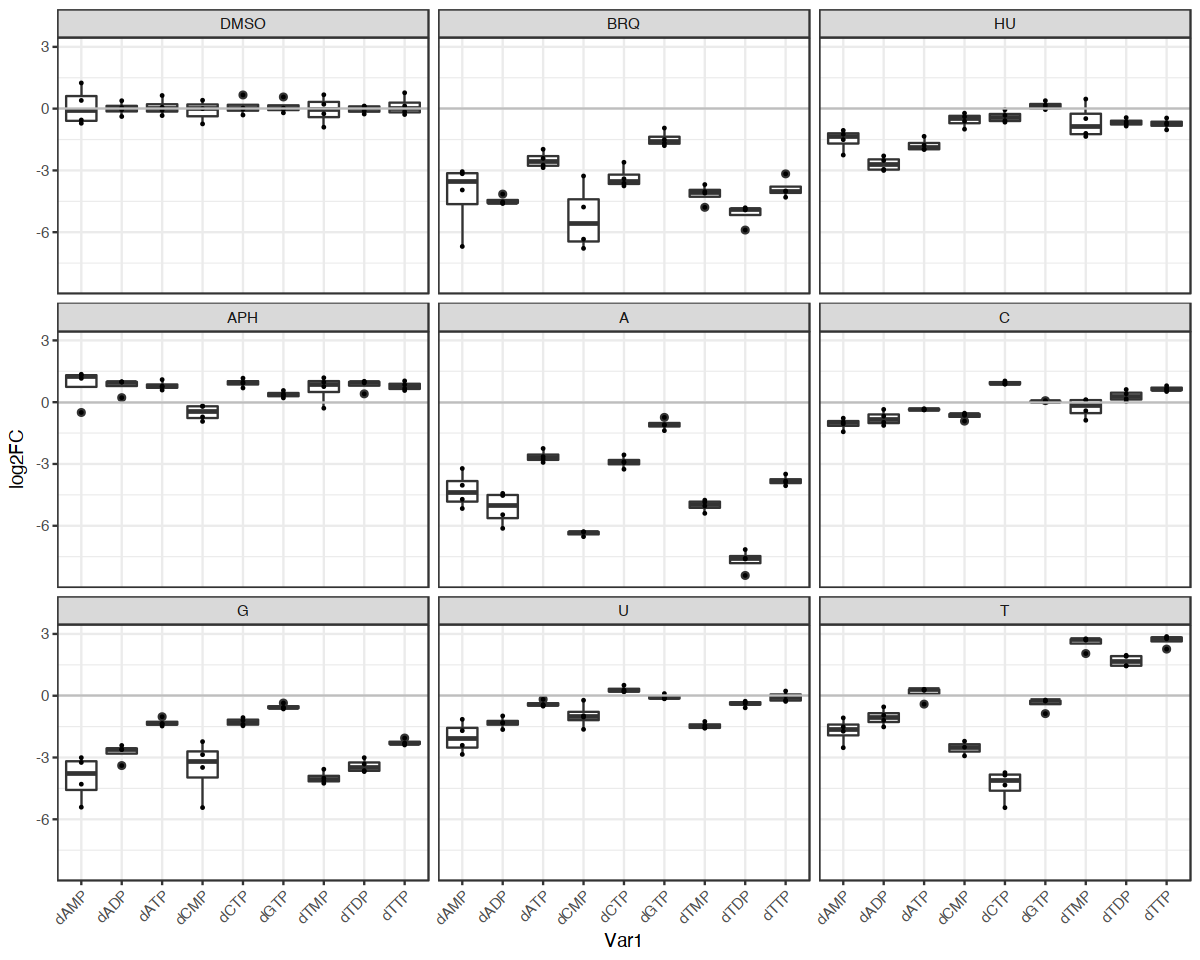

In [168]:
dntps = c("dAMP", "dADP", "dATP", "dCMP", "dCTP", "dGTP", "dTMP", "dTDP", "dTTP")
plot_vals(dntps, xax = "Var1",
          unique(er_sample_to_tx$tx), w=10, h=8, s=0.3) + 
          facet_wrap(facets = vars(tx), nrow=3)

#           facet_wrap(facets = vars(tx), nrow=3, scales = "free")

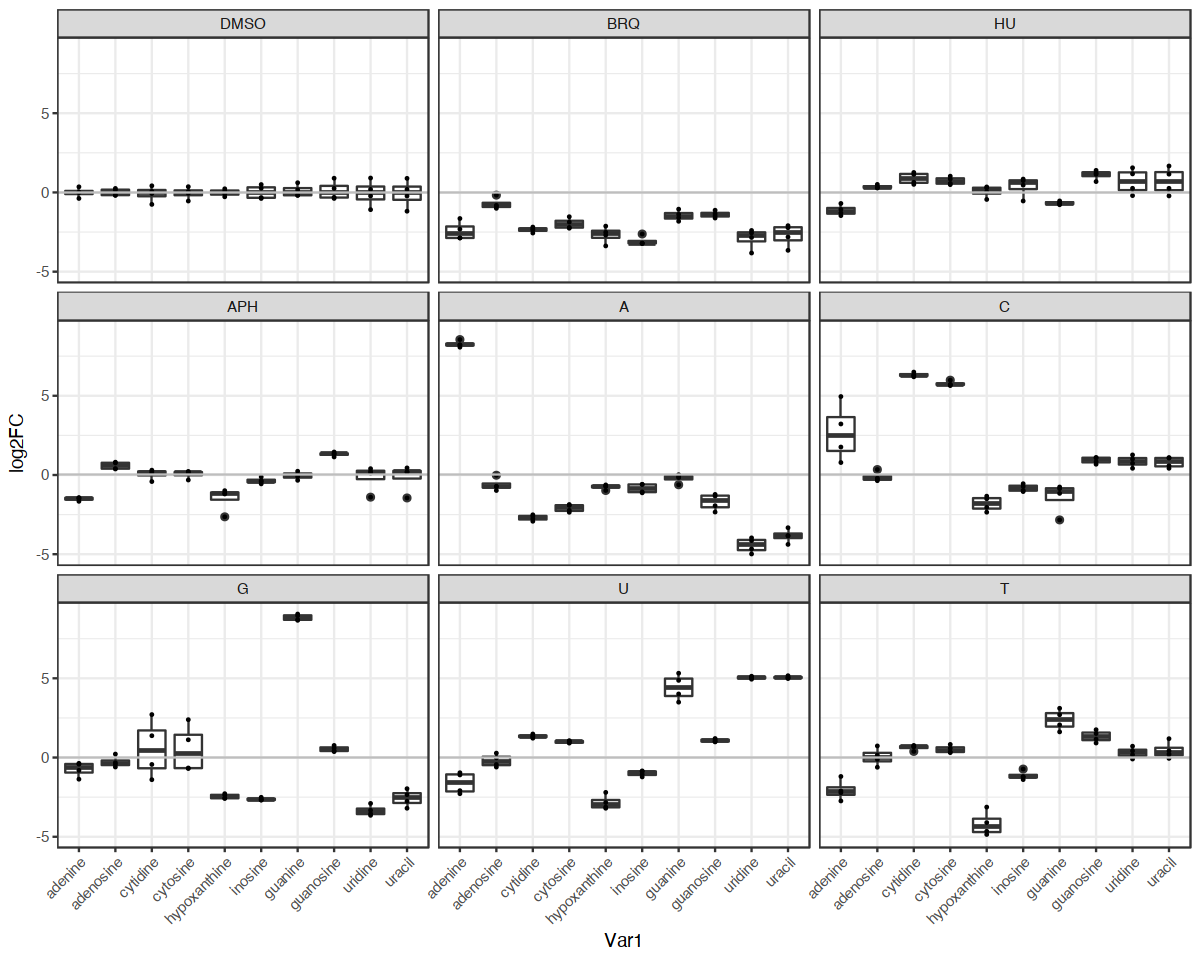

In [180]:
nucleosides = c("adenine", "adenosine", "cytidine", "cytosine", "hypoxanthine", "inosine", "guanine", "guanosine",
                "uridine", "uracil")
plot_vals(nucleosides, xax = "Var1",
          unique(er_sample_to_tx$tx), w=10, h=8, s=0.3) + 
          facet_wrap(facets = vars(tx), nrow=3)
# plot_vals(nucleosides,
#           unique(sample_to_tx$kd), w=6, h=10, s=0.3) + 
#           facet_grid(rows = vars(Var2), scales = "free")

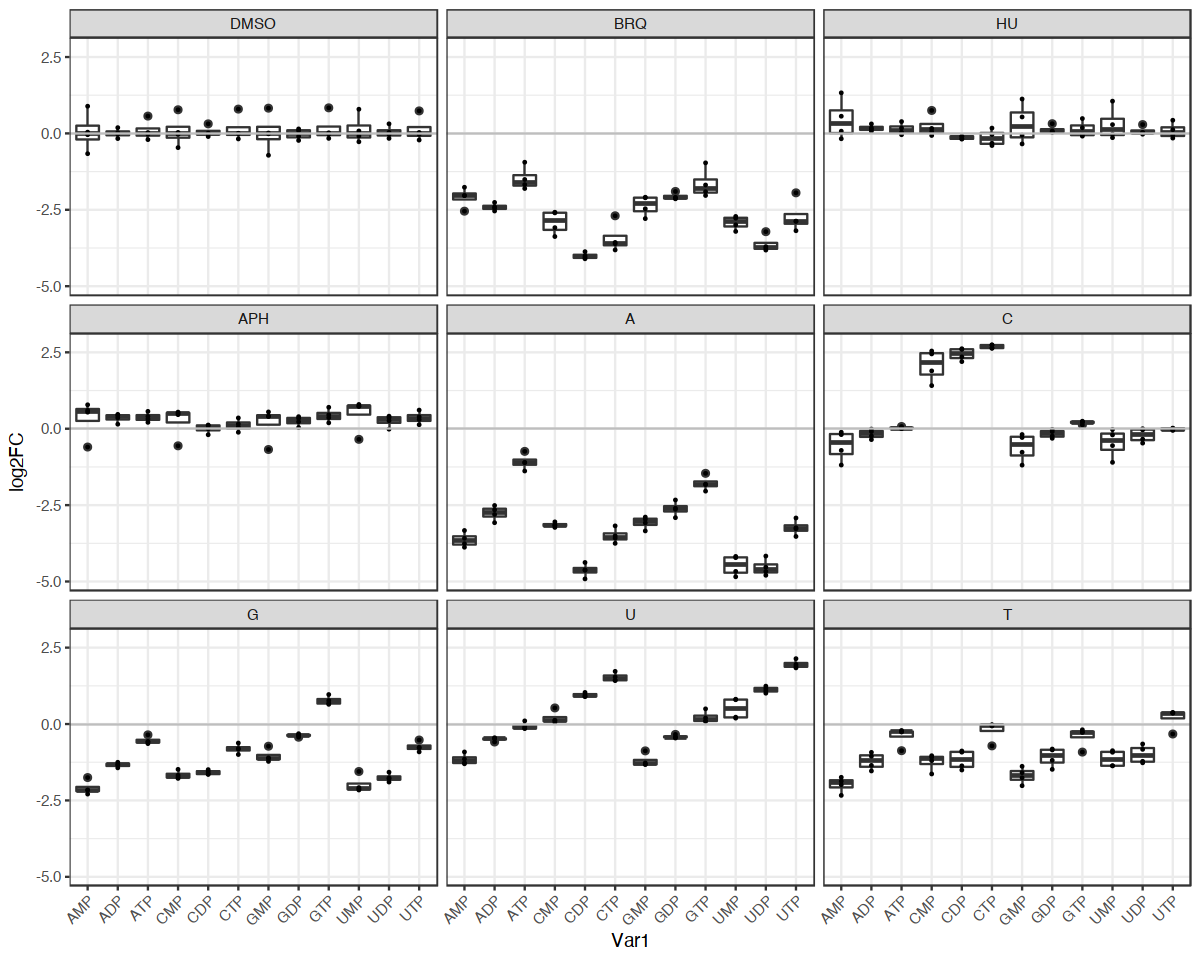

In [170]:
rntps = c("AMP", "ADP", "ATP", "CMP", "CDP", "CTP",
            "GMP", "GDP", "GTP", "UMP", "UDP", "UTP")
plot_vals(rntps, xax = "Var1",
          unique(er_sample_to_tx$tx), w=10, h=8, s=0.3) + 
          facet_wrap(facets = vars(tx), nrow=3)

pdf 
  2

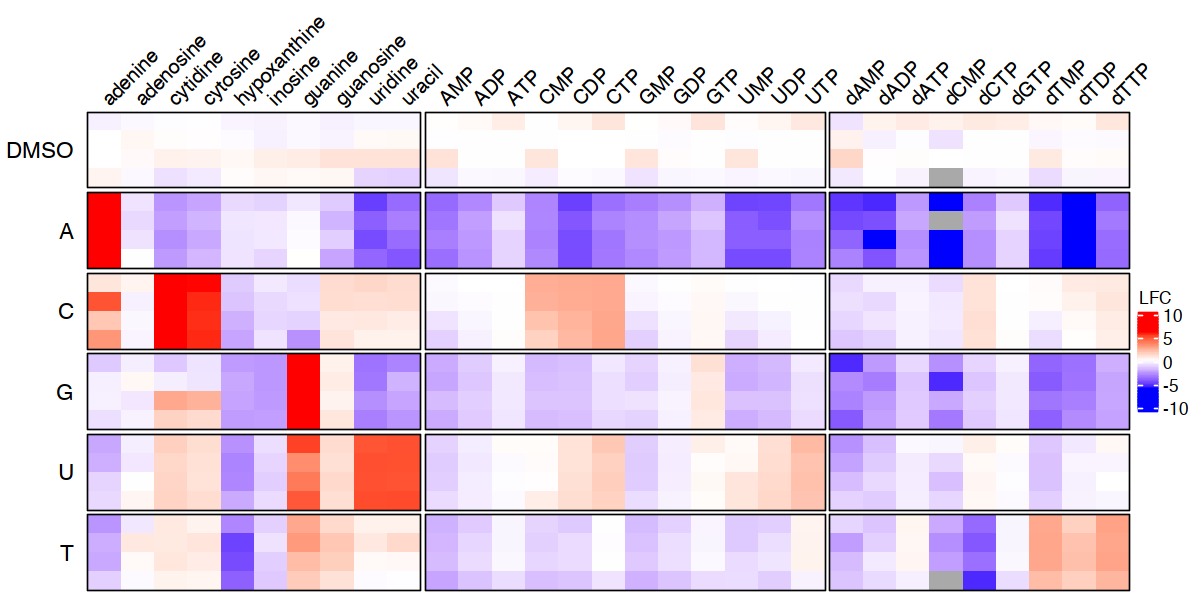

In [207]:
er_nt_exognt = er_rr_data_zero_lfc[c(rntps, nucleosides, dntps),c(1,3,2,4,20,19,17,18,24,21,23,22,28,27,25,26,
                                                                  29,32,31,30,34,33,35,36)]

options(repr.plot.width=10, repr.plot.height=5)

pdf("./220119_bd295_exog_nt_erhoxa9.pdf", width=10, height=5)
d = Heatmap(t(er_nt_exognt), cluster_columns = FALSE,
        cluster_rows=FALSE,
        row_split = factor(c(rep("DMSO",4), rep("A",4), rep("C",4),
                      rep("G",4), rep("U",4), rep("T",4)), 
                           levels=c("DMSO", "A", "C", "G", "U", "T")),
        column_split = factor(c(rep("ribo", 12), rep("base", 10), rep("dNTP",9)),
                            levels=c("base", "ribo", "dNTP")),
        show_row_names = FALSE, col=col_fun, row_title_rot = 0,
        na_col="darkgray", column_names_rot = 45, column_names_side = "top", 
            column_title = NULL, border = TRUE, heatmap_legend_param = list(title = "LFC"))
d
dev.off()
d